#  Прогнозирование заказов такси

Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час. Постройте модель для такого предсказания.

Значение метрики *RMSE* на тестовой выборке должно быть не больше 48.

Данные лежат в файле `taxi.csv`. Количество заказов находится в столбце `num_orders`.

## Подготовка

### Загрузка библиотек и установление констант

In [ ]:
# подгружаем и обновляем необходимые библиотеки -2
# "выключаем звук" (строчки с текстом по мере загрузки) с помощью -q

!pip install scikit-learn==1.5.2 -q # обновление для корректной работы некоторых частей кода, напр. Optuna

# модели
#!pip install catboost -q # СatBoost, вроде есть в пакете "по-умолчанию"
!pip install lightgbm -q # LightGBM

# признаки
!pip install shap -q # оценка важности признаков

In [ ]:
# подключаем библиотеки
import pandas as pd # работа с данными в формате таблиц
import numpy as np # математические операции и работа с массивами
import time # расчет времени выполнения функций

# расширение дисплея для отображения информации
from IPython.display import display

# "выключаем" красные предупреждения.
#import warnings
#warnings.filterwarnings('ignore', category=FutureWarning)

# визуализация данных
import seaborn as sns # для некоторых графиков и матриц
import matplotlib.pyplot as plt # для некоторых графиков

# работа с временными рядами
from statsmodels.tsa.seasonal import seasonal_decompose # тренд, сезонность, остатки

# подготовка данных
from sklearn.model_selection import train_test_split # для разбивки на выборки для МО
from sklearn.preprocessing import StandardScaler # масштабирование количественных признаков

# автоподбор параметров моделей
from sklearn.model_selection import (GridSearchCV,  # сплошной перебор параметров
                        # для разделения временных рядов на обучающие и тестовые выборки с учётом порядка следования данных:
                                    TimeSeriesSplit) # "аналог" "кросс-валидации" для временных рядов

# метрики моделей
from sklearn.metrics import mean_squared_error # MSE(среднеквадратичная ошибка) и RMSE(ее корень), не работает с Optuna

# модели
from sklearn.dummy import DummyRegressor # дамми-модель
from sklearn.linear_model import LinearRegression # линейная регрессия
from sklearn.tree import DecisionTreeRegressor # дерево решений
from sklearn.ensemble import RandomForestRegressor # лес случайных деревьев
import lightgbm as lgb # для некоторых действий по подготовке
from lightgbm import LGBMRegressor # LightGBM модель
from catboost import CatBoostRegressor # CatBoost

# для оценки вкладов признаков
#from sklearn.inspection import permutation_importance # важность перестановок
import shap # с помощью значений Шепли
shap.initjs()   # отображение результатов

In [ ]:
# задаем настройки отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.options.display.float_format ='{:,.2f}'.format
sns.set_theme(style='whitegrid', palette='pastel')
sns.set_context(
    'notebook',
    rc={
        'font.size':12,
        'axes.titlesize':16,
        'axes.labelsize':12,
        'legend.fontsize':12,
        'figure.figsize':(14, 7)
    }
)

## warnings.simplefilter(action='ignore', category=FutureWarning)
#pd.options.mode.chained_assignment = None

# задаем класс для стилизации вывода метода .print()
class color:
   PURPLE = '\033[95m'
   CYAN = '\033[96m'
   DARKCYAN = '\033[36m'
   BLUE = '\033[94m'
   GREEN = '\033[92m'
   YELLOW = '\033[93m'
   RED = '\033[91m'
   BOLD = '\033[1m'
   UNDERLINE = '\033[4m'
   END = '\033[0m'

In [ ]:
# задаем константы

# для фиксации объектов тренировочной и тестовой выборок, а также в некоторых рандомах
RANDOM_STATE = 42

# для пропорционального разделения датасета на тренировочную и тестовую выборки
TEST_SIZE = 0.1

**Вывод**

Необходимые для работы библиотеки подключены, константы заданы, стиль отображения настроен.

### Загрузка данных и краткий обзор

Прежде чем начать работу, мы должны убедиться, что наш датасет может стать временным рядом, а также узнать, в каком из столюцов содержатся даты.

In [ ]:
#ссылки сделаны неработоспособными в рамках этичности работы с предоставляемыми данными
# загрузка датасета (обычная)
try:
    taxi = pd.read_csv('/datasets/taxi.csv')
except:
    taxi = pd.read_csv('https://адрес_удален/datasets/taxi.csv')

In [ ]:
taxi.head() # смотрим

,datetime,num_orders
0,2018-03-01 00:00:00,9
1,2018-03-01 00:10:00,14
2,2018-03-01 00:20:00,28
3,2018-03-01 00:30:00,20
4,2018-03-01 00:40:00,32


In [ ]:
taxi.info() # краткая информация

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   datetime    26496 non-null  object
 1   num_orders  26496 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 414.1+ KB


Датасет соответствует задаче: в первом столбце у нас дата и время заказа в формате '%Y-%m-%dT%H:%M:%S' (однако не соответствует тип данных, который тут вместо 'object' вместо 'datetime64'), во втором - количество заказов. Также мы можем наблюдать, что временной отрезок между строками составляет 10 минут.

Видимых пропусков мы не наблюдаем, но вдруг у нас есть пропущенные периоды?

In [ ]:
# проверка пропущенных периодов
# диапазон дат с помощью функции date_range из библиотеки pandas
df_expected_range = pd.date_range(start=taxi.set_index('datetime').index.min(), # начальная дата диапазона
                                  end=taxi.set_index('datetime').index.max(), # конечная дата диапазона
                                  freq='10M') # временной промежуток
# обнаруживаем потерянные значения
df_missing = df_expected_range.difference(taxi.set_index('datetime').index)

if df_missing.shape[0] > 0: # выводим пропущенные значения
    print(color.BLUE + color.BOLD + f"Пропущенные промежутки времени:" + color.END + f"\n{df_missing}")
else:
    print(color.BLUE + color.BOLD + f"Нет пропущенных промежутков времени" + color.END)

Пропущенные промежутки времени:
DatetimeIndex(['2018-03-31'], dtype='datetime64[ns]', freq=None)


Так и есть: в данных не хватает информации за все сутки 31 марта. Но это лишь один день из полугода, поэтому сильно снизить качество модели это не сможет.

Проверим, нет ли у нас дубликатов.

In [ ]:
taxi.duplicated().sum() # проверка дубликатов

0

Дубликатов не обнаружено.

Так как данные соотвествуют задаче, мы перезагрузим датасет с учетом уже известной нам информации о нем.

In [ ]:
# загрузка датасета (с временными рядами)
try:
    taxi = pd.read_csv('/datasets/taxi.csv', # путь
                       index_col=[0], # первый столбец использовать как индекс
                       parse_dates=[0]) # даты в первом столбце должны юыть интерпретированы как даты
except:
    taxi = pd.read_csv('https://code.s3.yandex.net/datasets/taxi.csv', index_col=[0], parse_dates=[0])

In [ ]:
taxi.head() # смотрим

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


Превращение информации о времени в индексы прошло успешно. Проверим, в хронологическом ли у нас порядке данные?

In [ ]:
#проверка хронологического порядка
if taxi.index.is_monotonic == True:
    print(color.BLUE + color.BOLD + f"Данные расположены в хронологическом порядке" + color.END)
else:
    print(color.BLUE + color.BOLD + f"Хронологическом порядок нарушен" + color.END)

Данные расположены в хронологическом порядке


Так как наши данные уже находятся в хронологическом порядке, дополнительно сортировать их не требуется.

In [ ]:
taxi.info() # краткая информация

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


В нашем датасете содержится информация за период с 2018-03-01 00:00:00 по 2018-08-31 23:50:00 (то есть за полгода). Пропуски в данных отсутствуют.

Посмотрим график временого ряда для краткого обзора.

<AxesSubplot:xlabel='datetime'>

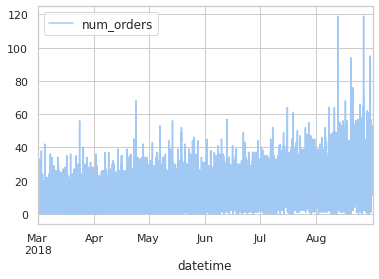

In [ ]:
# строим график
taxi.plot()

Мы уже можем наблюдать наличие пиков в разные периоды (особенно высокие - в августе), а также тенденцию на увеличение количества заказов.

Также мы можем видеть, что в нкоторые периоды заказов не было вовсе.

Более подробно будем изучать данные позже.

**Выводы**

- Данные загружены и проведено предварительное исследование.
- Для анализа заказчиком предоставлены данные за период в полгода: c 2018-03-01 00:00:00 по 2018-08-31 23:50:00.
- Временной отрезок в данных составляет 10 минут, отсутствуют данные за 31 марта.
- Дубликаты в данных отсутствуют.
- Имеются пики по количеству заказов в различные периоды, также видна тенденция на увеличение их количества. Также имеются периоды, в которые заказы отсутвовали вовсе.

## Анализ

### Ресемплирование

10 минут - это досточно подробно, но не очень удобно в рамках задачи. Поэтому, для проведения анализа данные необходимо сначала ресемплировать по одному часу, учитывая общее количество заказов за этот час (так наша задача - прогнозирование количества заказов на следующий час).

In [ ]:
# ресемплируем
taxi = taxi.resample('1H').sum()

In [ ]:
taxi.head(24) # смотрим

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43
2018-03-01 05:00:00,6
2018-03-01 06:00:00,12
2018-03-01 07:00:00,15
2018-03-01 08:00:00,34


In [ ]:
taxi.info() # краткая информация

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: H
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB


Временной период остался прежним, а вот количество строк стало меньше. Поэтому теперь анализ проводит станет гораздо удобнее.

**Вывод**

Для соответветствия данных поставленной задаче мы произвели рнесемплирование данных по одному часу.

### Предварительный анализ

Начнем общий анализ, пока без привязки к датам.

In [ ]:
# числовое описание данных (с транспонированием)
taxi.describe().T

,count,mean,std,min,25%,50%,75%,max
num_orders,"4,416.00",84.42,45.02,0.00,54.00,78.00,107.00,462.00


Мы уже можем набюдать, что по-прежнему есть периоды, заказы в которые не поступали. А есть напротив, очень насыщенные периоды, где количество заказов составляет более четырех с половиной сотен. Возможно, это связано с прилетом нескольких самолетов в аэропорт одновременно?

Посмотрим распределение чуть детальнее.

In [ ]:
# создание функции для будущего описания числовых недискретных признаков
def discr_num(col_data, title, x_label):
    # Создание графиков: гистограмма и диаграмма размаха
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(16, 8))

    # Гистограмма
    sns.histplot(data=col_data, bins=50, kde=True, ax=axs[0])
    axs[0].set_xlabel(x_label)
    axs[0].set_ylabel('Количество попаданий в выборку')
    axs[0].set_title('Гистограмма')

    # Диаграмма размаха
    sns.boxplot(data=col_data, ax=axs[1])
    axs[1].set_xlabel(x_label)
    axs[1].set_title('Диаграмма размаха')

    # Заголовок графиков
    fig.suptitle(title)

    # Показать графики и вернуть описательные статистики
    plt.show()
    return col_data.describe()

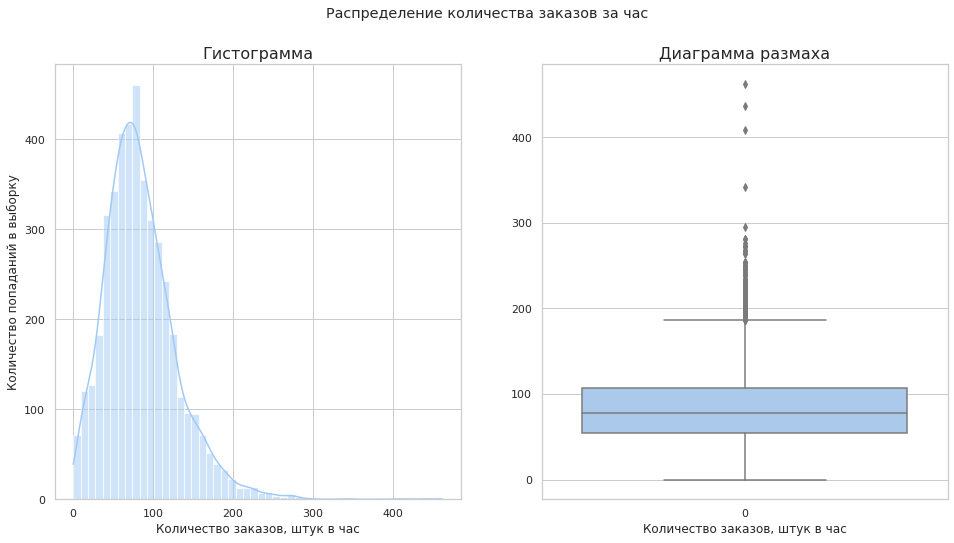

count   4,416.00
mean       84.42
std        45.02
min         0.00
25%        54.00
50%        78.00
75%       107.00
max       462.00
Name: num_orders, dtype: float64


In [ ]:
# Вызов функции discr_num и ее вывод для количества заказов
print(discr_num(taxi['num_orders'],
                'Распределение количества заказов за час',
                'Количество заказов, штук в час'))

Распределение можно считать нормальны, пик его смещен влево. С точки зрения диаграммы размаха количества заказов более 200 в час можно считать аномалией, а более трехсот - выбросами. Если бы задача не была связана с временными рядами, то указанные строки могли бы быть потенциально удалены (после предварительного изучения, которое бы подтвердило или опровергло возможность удаления). Но в данном случае мы можем лишь взглянуть поближе на данные строки.

In [ ]:
# считаем количество строк более 200 заказов в час
print(color.BLUE + color.BOLD + f"Количество строк с заказами более 200 штук в час составило: "\
      + color.END +f"{len(taxi[taxi['num_orders'] > 200])}")

Количество строк с заказами более 200 штук в час составило: 81


Немало, поэтому не похоже на ошибку

In [ ]:
# считаем количество строк более 300 заказов в час
print(color.BLUE + color.BOLD + f"Количество строк с заказами более 300 штук в час составило: "\
      + color.END +f"{len(taxi[taxi['num_orders'] > 300])}")

Количество строк с заказами более 300 штук в час составило: 4


In [ ]:
taxi[taxi['num_orders'] > 300] # выводим эти строки

,num_orders
datetime,
2018-08-13 02:00:00,437
2018-08-20 02:00:00,462
2018-08-27 02:00:00,408
2018-08-30 17:00:00,342


Заказы с количеством более 400 штук в час совершались раз в неделю в одно и тоже время с середины августа. Возможно, это действительно было время прилета большого самолета (или нескольких сразу), например, с курорта (так как август).

Посмотрим на строки без заказов.

In [ ]:
taxi[taxi['num_orders'] == 0] # выводим эти строки

,num_orders
datetime,
2018-04-06 06:00:00,0


Такой период (ни одного заказа в час) был в истории наблюдения лишь раз. Возможно, это был программный сбой сервиса либо его обновление, ввиду чего возможность заказа была недоступна.

**Выводы**

- Распределение количества заказов в час является нормальным и смещенным влево.
- Наиболее сильные выбросы (более 400 заказов в час) приходятся на один и тот же день недели и одно и то же время в августе, что говорит о повторяющемся их характере и том, что данные строки - настоящие. Совпадение дня недели и времени у данных строк может быть связно с прибытием самолета с большим количестовом пассажиров на борту и плохой доступностью общественного транспорта в это время суток.
- Час без заказов за имеющийся период наблюдений случился лишь один раз. Это может быть связано с програмным сбоем в работе сервиса либо обновлением програмного обеспечения, ввиду чего возможность заказа в указанное время была недоступна.

### Тренд и сезонность

Теперь перейдем к анализу данных именно как временного ряда. Разложим временной ряд на тренд и сезонную компоненту и выведем график этих составляющих ряда.

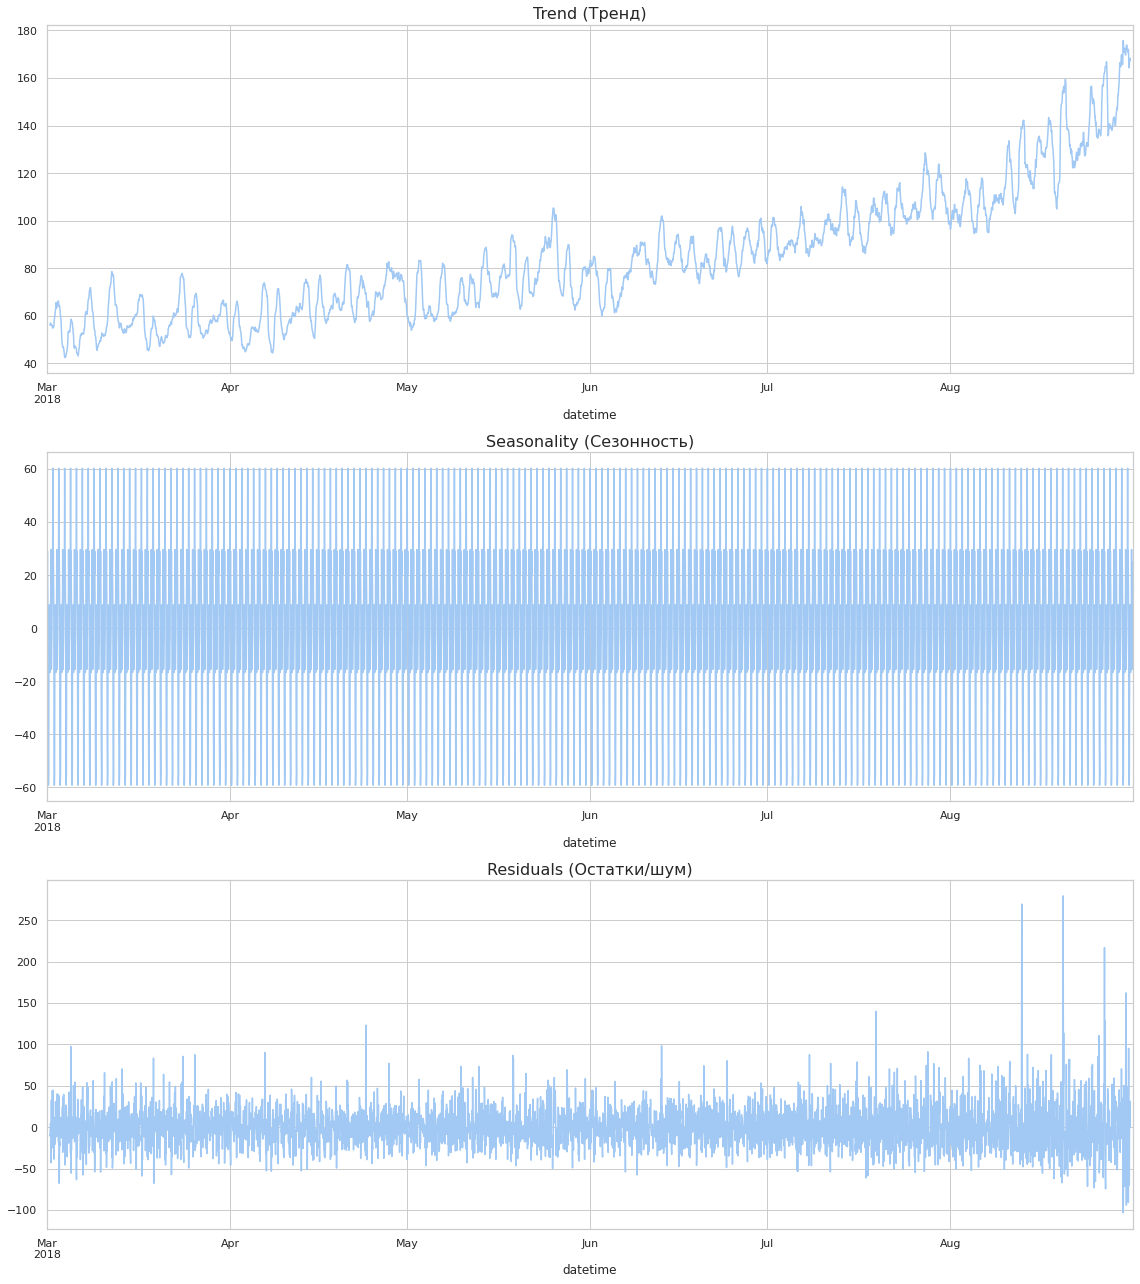

In [ ]:
# разложение временого ряда на тренд и сезонность
decomposed = seasonal_decompose(taxi) # декомпозируем

plt.figure(figsize=(16, 18))
plt.subplot(311)
# Чтобы график корректно отобразился, указываем его
# оси ax, равными plt.gca() (англ. get current axis,
# получить текущие оси)
decomposed.trend.plot(ax=plt.gca())
plt.title('Trend (Тренд)')
plt.subplot(312)
decomposed.seasonal.plot(ax=plt.gca())
plt.title('Seasonality (Сезонность)')
plt.subplot(313)
decomposed.resid.plot(ax=plt.gca())
plt.title('Residuals (Остатки/шум)')
plt.tight_layout()

Мы можем наблюдать тренд на увеличение заказов: с около 50 в марте до 90 и более в августе. Причем заметный рост начался в июле, что может быть связано с началом сезона отпусков. Также это может усложнить прогнозирование для модели (изменение характера данных и рост количества в отрезке, который она будет предсказывать).

А вот сезонность как будто присутствует, но видна она плохо. Поэтому попробуем уменьшить период наблюдения для нее. Например, до месяца.

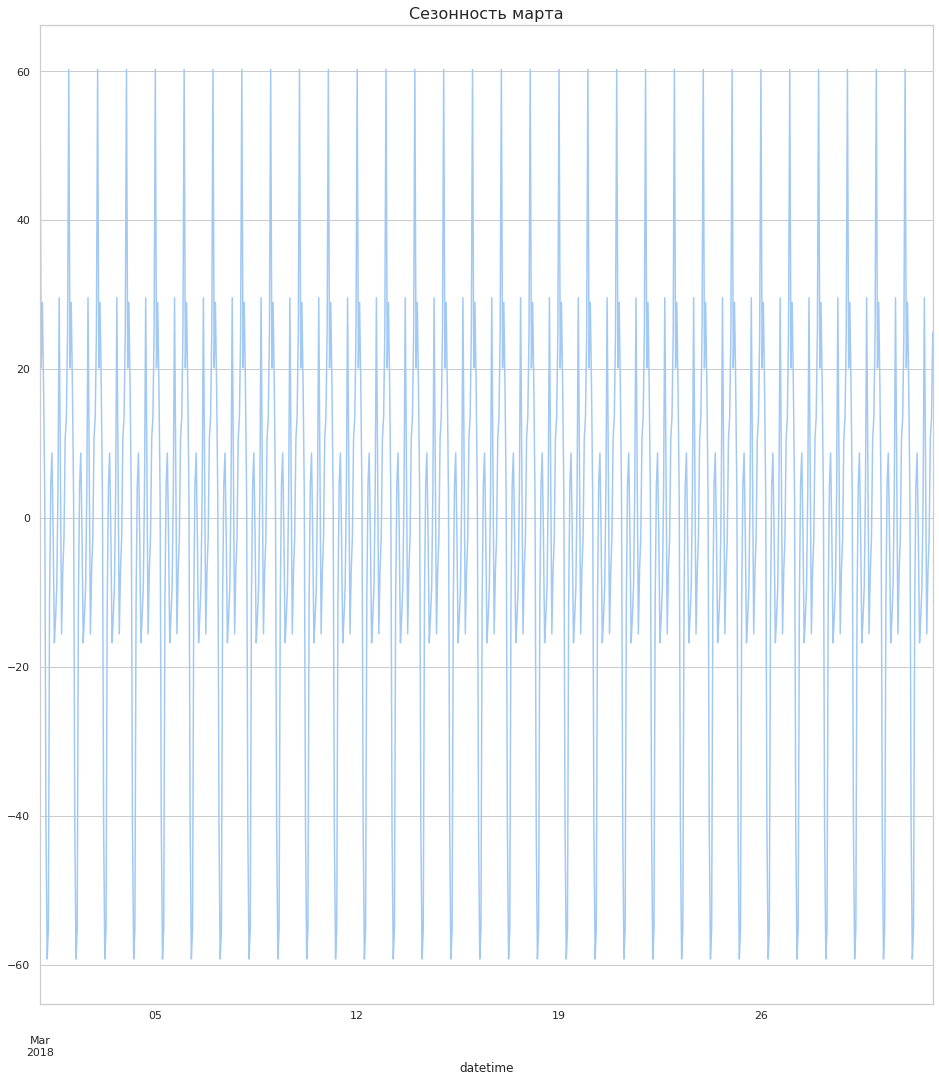

In [ ]:
# смотрим сезонность для марта
plt.figure(figsize=(16, 18))
decomposed.seasonal['2018-03-1':'2018-03-31'].plot(ax=plt.gca())
plt.title('Сезонность марта');

Здесь уже четко видна система: "ритм" в рамках месяца повторяется многократно.

Снова изменим масштаб. На этот раз - до одной недели.

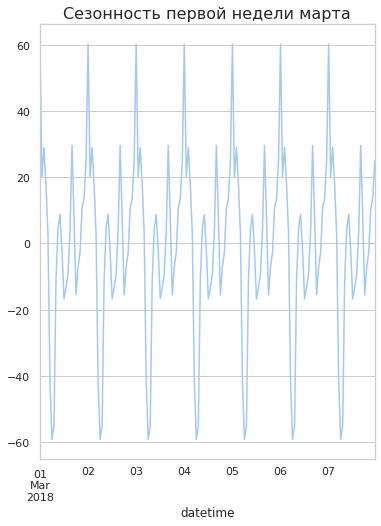

In [ ]:
# смотрим сезонность для первой недели марта
plt.figure(figsize=(6, 8))
decomposed.seasonal['2018-03-1':'2018-03-07'].plot(ax=plt.gca())
plt.title('Сезонность первой недели марта');

Теперь мы можем четко наблюдать сезонность в рамках суток.

Еще больше "приблизим микроскоп" сократив период до дня.

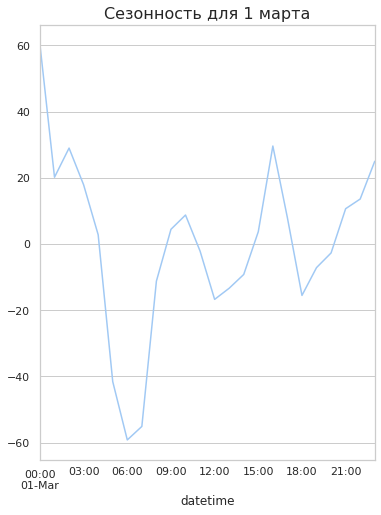

In [ ]:
# смотрим сезонность для первого дня марта
plt.figure(figsize=(6, 8))
decomposed.seasonal['2018-03-1':'2018-03-01'].plot(ax=plt.gca())
plt.title('Сезонность для 1 марта');

В течении дня несколько пиков, а максимальное количество заказов характерно для времени около полуночи. Это может быть связано как с прибытием междугородного/международного транспорта с большим количеством пассажиров в данное время и/или плохой работой или не работой в это время/в данном месте (например, аэропорт за городом) общественного транспорта, что затрудняет пассажирам путь домой и им приходится вызывать такси.

Самое "мертвое" время (с минимальным количеством заказов) - около шести утра. Возможно, транспорт с большим количеством пассажиров отсутствует (не прибывает), а жителям города еще рано отправляться на работу. И, если ранее выявленный отрезок времени с полностью отсутствующими закзами, действительно был связан с обновлением программного обеспечения или техработами сервиса, то низкий уровень заказов в шесть утра объясняет, почему именно это время было выбрано для обслуживания сервиса (так как потери клиентов минимальны).

Еще раз взглянем на тренд, но с учетом скользящего среднего и скользящего стандартного отклонения, чтобы понять, является ли временной ряд стационарным (так как глядя на тренд без данных компонентов мы можем предполождить его нестационарность).

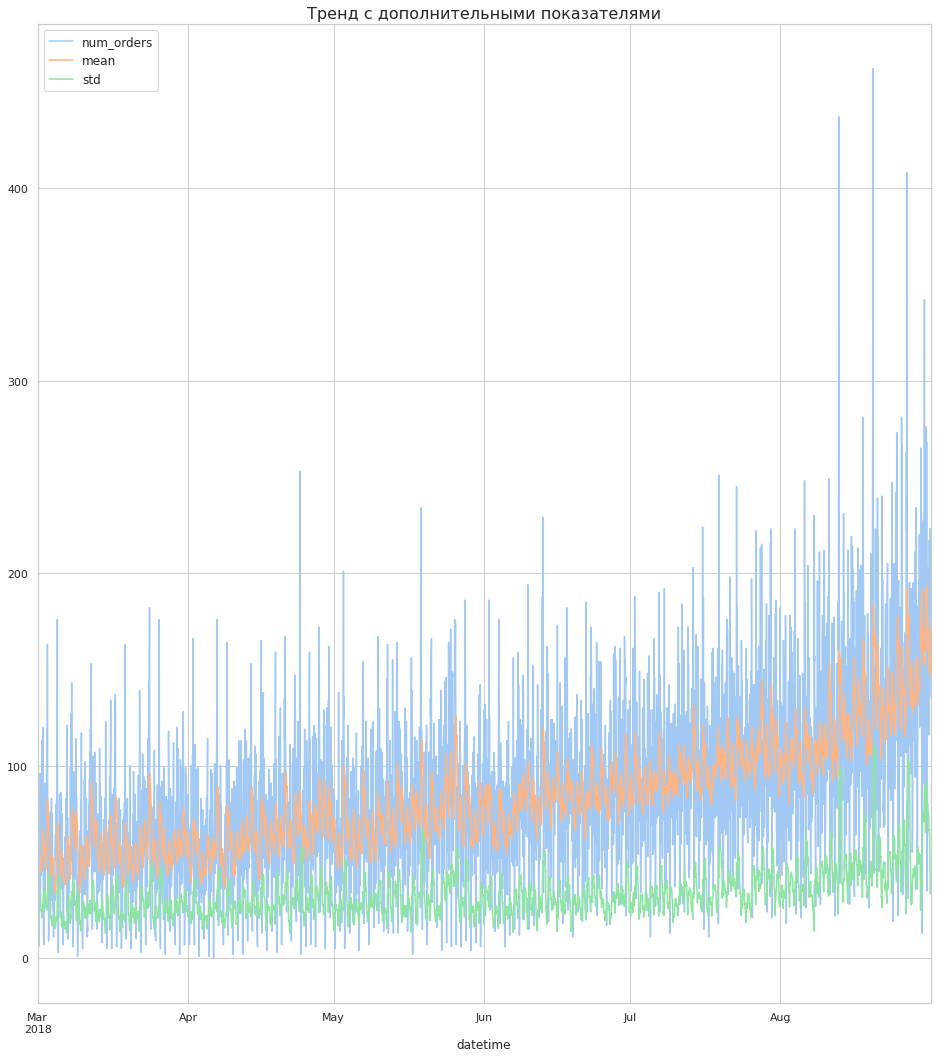

In [ ]:
# дополнительный взгляд на тренд
temp = taxi.copy() # создаем копия для изменений для дополнительного анализа

temp['mean'] = temp['num_orders'].rolling(15).mean() # скользящее среднее
temp['std'] = temp['num_orders'].rolling(15).std() # скользящее стандартное отклонение

#plt.figure(figsize=(16, 18)) # не срабаотывает
temp.plot()
plt.gcf().set_size_inches(16, 18)  # задание размера после создания фигуры
plt.title("Тренд с дополнительными показателями")
plt.show()

Теперь мы точно видим, что наш ряд нельзя считать стационарным, а значит пронозировать его будет сложнее из-за изменения свойств.

**Выводы**

- Виден тренд на увеличение заказов в час: от середнего около 50 в марте, до около 100 и выше в августе. Сам процесс усилинного роста начинается с июня: возможно на него оказывает влияние начало сезона отпусков.
- Имеющися временной ряд нельзя считать стационарным, а пронозировать его будет сложнее из-за изменения свойств.
- Сезонность можно обнаружить в рамках суток:
    * В течении дня несколько пиков, а максимальное количество заказов характерно для времени около полуночи. Это может быть связано как с прибытием междугородного/международного транспорта с большим количеством пассажиров в данное время и/или плохой работой или не работой в это время/в данном месте (например, аэропорт за городом) общественного транспорта, что затрудняет пассажирам путь домой и им приходится вызывать такси.
    * Самое "мертвое" время (с минимальным количеством заказов) - около шести утра.

### Дополнительные признаки (создание и анализ)

Прежде, чем приступать к обучению, необходимо создать признаки, на которых оно и будет происходить. Мы уже видели сезонность в рамках суток, также анализ аномально высокого количества заказов позволяет также предположить влияние дня недели. Тренд же на увеличение количества заказов также рекомендует учитывать и месяц. Год же не имеет значения, так как он у нас одинаковый.

Также ввиду того, что временной ряд у нас не стационарный, необходимо будет учитывать смещения. Так как сезонность у нас лучше всего проявилась в рамках суток, будем брать значение 24 для использования в смещении и вычеслении среднего.

Создадим новые признаки.

In [ ]:
data = taxi.copy() # создаем копию для преобразования

In [ ]:
# функция добавления новых признаков
def make_features(data, max_lag, rolling_mean_size):
    # календарные признаки
    data['month'] = data.index.month # месяц
    data['day'] = data.index.day # день месяца
    data['dayofweek'] = data.index.dayofweek # день недели
    data['hour'] = data.index.hour # час

    # отстающие значения
    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['num_orders'].shift(lag)

    # скользящее среднее по определенному количеству значений
    data['rolling_mean'] = data['num_orders'].shift().rolling(rolling_mean_size).mean()

    return data

In [ ]:
# применение функции
make_features(data, 24, 24)
data.head() # вывод результата

,num_orders,month,day,dayofweek,hour,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rolling_mean
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-03-01 00:00:00,124,3,1,3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 01:00:00,85,3,1,3,1,124.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 02:00:00,71,3,1,3,2,85.00,124.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 03:00:00,66,3,1,3,3,71.00,85.00,124.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 04:00:00,43,3,1,3,4,66.00,71.00,85.00,124.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Новые признаки созданы. Попробуем проанализировать дополнительно некоторые из них.

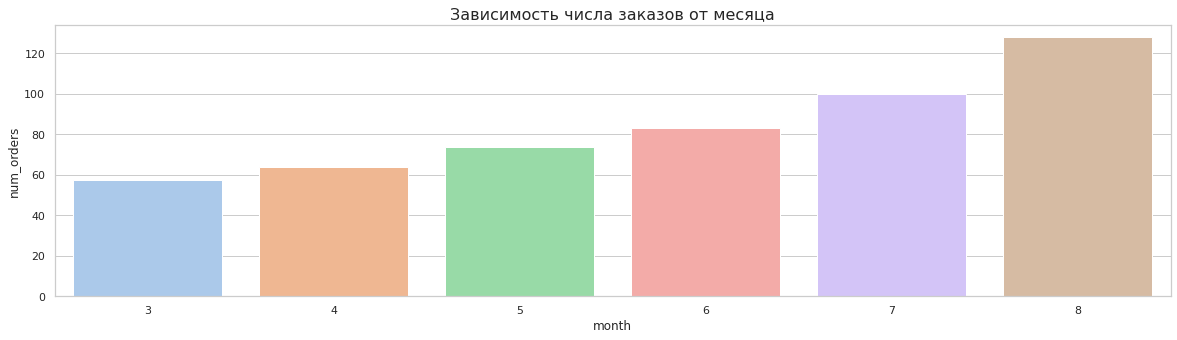

In [ ]:
# смотрим влияние месяца
temp = data.pivot_table(index=['month'],
                              values='num_orders',
                              aggfunc='mean')
plt.figure(figsize=(20,5))
sns.barplot(x='month', y='num_orders',
            data=temp.reset_index())
plt.title('Зависимость числа заказов от месяца')
plt.show()

Здесь мы снова наблюдаем рост числа заказов от начала к концу периода.

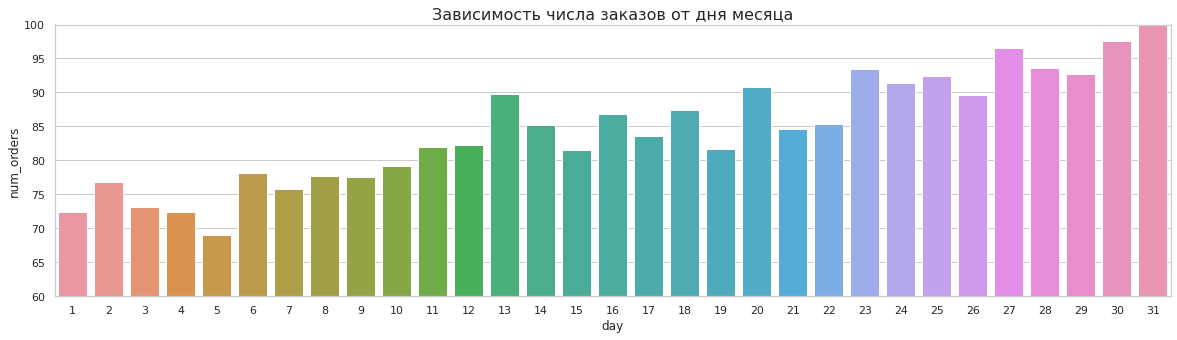

In [ ]:
# смотрим влияние дня месяца
temp = data.pivot_table(index=['day'],
                              values='num_orders',
                              aggfunc='mean')
plt.figure(figsize=(20,5))
sns.barplot(x='day', y='num_orders',
            data=temp.reset_index())
plt.title('Зависимость числа заказов от дня месяца')
plt.ylim(60, 100)
plt.show()

Мы можем наблюдать, что от начала месяца к концу среднее количество заказов растет.

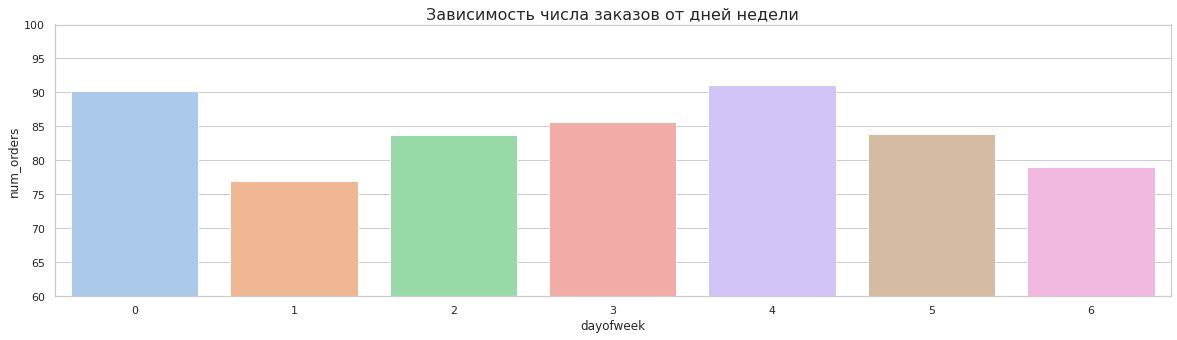

In [ ]:
# смотрим влияние дней недели
temp = data.pivot_table(index=['dayofweek'],
                              values='num_orders',
                              aggfunc='mean')
plt.figure(figsize=(20,5))
sns.barplot(x='dayofweek', y='num_orders',
            data=temp.reset_index())
plt.title('Зависимость числа заказов от дней недели')
plt.ylim(60, 100)
plt.show()

В пятницу и воскресенье заказов обычно больше всего. Вероятно это может быть связано с поездками на выходные в пятницу и возвращение из них в воскресенье.

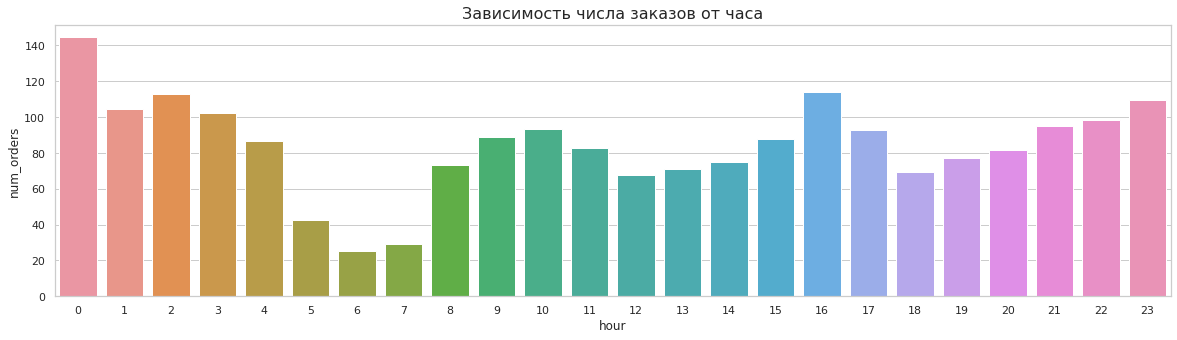

In [ ]:
# смотрим влияние от часа
temp = data.pivot_table(index=['hour'],
                              values='num_orders',
                              aggfunc='mean')
plt.figure(figsize=(20,5))
sns.barplot(x='hour', y='num_orders',
            data=temp.reset_index())
plt.title('Зависимость числа заказов от часа')
plt.show()

Здесь мы можем наблюдать то же, что уже видели ранее на графике сезонности: несколько пиков в течении суток с максимумом в полночь и с минимумом в шесть утра.

Теперь же посмотрим на корелляцию отстающих значений.

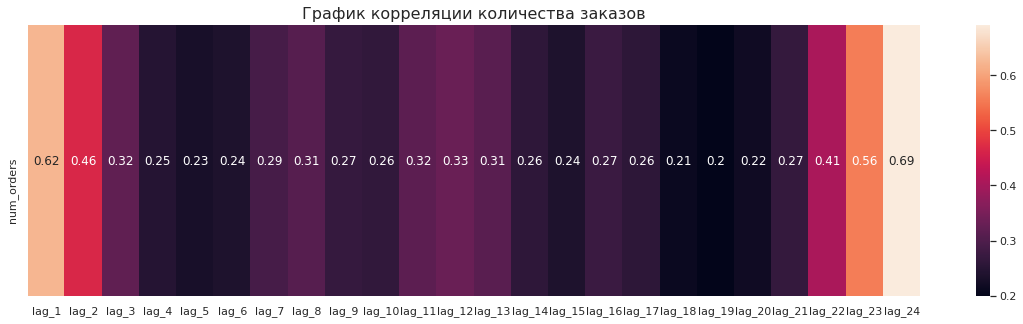

In [ ]:
# корреляция количества заказов
plt.figure(figsize=(20, 5))
sns.heatmap(
    data.drop(['day','month','dayofweek', 'hour', 'rolling_mean'], axis=1)
    .dropna().corr()[['num_orders']][1:].T, annot=True)
plt.title('График корреляции количества заказов')
plt.show()

Корреляция с целевым признаком присутствует везде, но наиболее тесная - с ближайшими часами до и после.

**Выводы**

Мы создали новые признаки, подходящие под нашу задачу. В результате их анализа мы:
- Снова увидели рост числа заказов от начала к концу исследуемого периода.
- Обнаружили, что от начала месяца к концу среднее количество заказов растет.
- В пятницу и воскресенье заказов обычно больше всего. Вероятно это может быть связано с поездками на выходные в пятницу и возвращение из никх в воскресенье.
- Для отстающих значений корреляция с целевым признаком присутствует везде, но наиболее тесная - с ближайшими часами до и после.

## Обучение

### Создание выборки

Для дополнительной проверки качества модели в процессе обучения в обычном случае мы бы использовали кросс-валидацию. Однако в случае временных рядов она не пременима, так как нам важен порядок данных. Поэтому мы будем использовать его альтернативу для данного случая: класс TimeSeriesSplit из модуля sklearn.model_selection. Он применяется для разделения временных рядов на обучающие и тестовые выборки с учётом порядка следования данных. Это полезно при работе с временными рядами, так как важно сохранять порядок данных и избегать утечки информации из будущего в обучающую выборку.

Теперь приступим к разделению данных на выборки и их дополнительную подготовку. Размер тестовых данных согласно требованию заказчика должен составлять 10% исходных данных, что мы зафиксировали константой в начале проекта.

In [ ]:
# задаем целевой признак
target = 'num_orders'

In [ ]:
def sep_data_time(data, target, test_size=TEST_SIZE, shuffle=False):
    """
    Разделяет данные на тренировочную и тестовую выборки, удаляет пропущенные значения
    и возвращает разделенные признаки и целевые переменные.

    Параметры:
    ----------
    data : DataFrame
        Исходный датафрейм с данными
    target : str
        Название целевой переменной
    test_size : float, default=TEST_SIZE
        Доля тестовой выборки
    shuffle : bool, default=False
        Нужно ли перемешивать данные перед разделением

    Возвращает:
    -----------
    X_train, X_test, y_train, y_test
        Разделенные признаки и целевые переменные
    """
    # разделение данных
    train, test = train_test_split(
        data,
        shuffle=shuffle,
        test_size=test_size
    )

    # удаление пропущенных значений только из тренировочной выборки
    train = train.dropna()

    # разделение на признаки и целевую переменную
    X_train = train.drop(target, axis=1)
    y_train = train[target]

    X_test = test.drop(target, axis=1)
    y_test = test[target]

    return X_train, X_test, y_train, y_test

In [ ]:
# применение функции разделения
X_train, X_test, y_train, y_test = sep_data_time(data=data, target=target)

In [ ]:
# проверка разбиения по количеству
print(color.BLUE + color.BOLD + f"Размер X_train: "\
      + color.END + f"{X_train.shape}")
print(color.BLUE + color.BOLD + f"Размер X_test: "\
      + color.END + f"{X_test.shape}")
print(color.BLUE + color.BOLD + f"Размер y_train: "\
      + color.END + f"{y_train.shape}")
print(color.BLUE + color.BOLD + f"Размер y_test: "\
      + color.END + f"{y_test.shape}")

Размер X_train: (3950, 29)
Размер X_test: (442, 29)
Размер y_train: (3950,)
Размер y_test: (442,)


In [ ]:
# первые строки тренировочного целевого
pd.DataFrame(y_train).head()

,num_orders
datetime,
2018-03-02 00:00:00,90
2018-03-02 01:00:00,120
2018-03-02 02:00:00,75
2018-03-02 03:00:00,64
2018-03-02 04:00:00,20


In [ ]:
# первые строки тестового целевого
pd.DataFrame(y_test).head()

,num_orders
datetime,
2018-08-13 14:00:00,102
2018-08-13 15:00:00,175
2018-08-13 16:00:00,144
2018-08-13 17:00:00,152
2018-08-13 18:00:00,104


In [ ]:
# начальный и конечный индекс тренировочной выборки
X_train.index.min(), X_train.index.max()

(Timestamp('2018-03-02 00:00:00', freq='H'),
 Timestamp('2018-08-13 13:00:00', freq='H'))

In [ ]:
# начальный и конечный индекс тестовой выборки
X_test.index.min(), X_test.index.max()

(Timestamp('2018-08-13 14:00:00', freq='H'),
 Timestamp('2018-08-31 23:00:00', freq='H'))

In [ ]:
# упорядоченность индексов в выборках
X_train.index.is_monotonic_increasing, X_test.index.is_monotonic_increasing

(True, True)

Количества признаков у тестовой и тренировочной выборок совпадают, количества строк у выборок с признаками совпадает с соответсвующим им целевым признаком, а тренировочные данные находятся до тестовых. Индексы в выборках расположены по порядку, и сами индексы у целевого не изменили свой формат.

Хотя у нас условно не слишком большая разбежка в порядках значений (от 0 до 462), но все равно масштабировние данных может улучшить качество модели.

Скалируем данные.

In [ ]:
# масштабирование
scaler = StandardScaler()  # инициализация скалера
# обучение на тренировочной выборке и её преобразование с преобразованием обратно в датафрейм с сохранением индексов
X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_train.head() # проверка

,month,day,dayofweek,hour,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rolling_mean
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-03-02 00:00:00,-1.42,-1.49,0.49,-1.66,-0.53,0.89,-0.32,-0.45,-0.86,-0.14,-0.89,-0.91,-0.32,-0.78,-1.20,-1.26,0.47,-0.37,-0.24,-1.16,-1.66,-1.74,-1.89,-0.92,-0.31,-0.18,0.19,1.21,-1.11
2018-03-02 01:00:00,-1.42,-1.49,0.49,-1.51,0.30,-0.53,0.90,-0.32,-0.45,-0.86,-0.14,-0.89,-0.91,-0.32,-0.78,-1.21,-1.26,0.47,-0.37,-0.24,-1.16,-1.66,-1.73,-1.89,-0.92,-0.31,-0.18,0.19,-1.18
2018-03-02 02:00:00,-1.42,-1.49,0.49,-1.37,1.08,0.30,-0.53,0.90,-0.32,-0.45,-0.86,-0.14,-0.89,-0.91,-0.32,-0.79,-1.21,-1.26,0.47,-0.37,-0.24,-1.16,-1.66,-1.73,-1.89,-0.92,-0.31,-0.18,-1.10
2018-03-02 03:00:00,-1.42,-1.49,0.49,-1.23,-0.09,1.08,0.30,-0.53,0.90,-0.32,-0.45,-0.86,-0.14,-0.89,-0.91,-0.32,-0.79,-1.21,-1.26,0.47,-0.37,-0.24,-1.16,-1.65,-1.73,-1.89,-0.92,-0.31,-1.10
2018-03-02 04:00:00,-1.42,-1.49,0.49,-1.08,-0.37,-0.09,1.08,0.30,-0.53,0.90,-0.32,-0.45,-0.86,-0.14,-0.89,-0.92,-0.32,-0.79,-1.21,-1.26,0.47,-0.37,-0.24,-1.16,-1.65,-1.73,-1.89,-0.92,-1.10


Данные тренировочной выборки успешно отмасштабированы: величины приведены к одному порядку, а исходные индексы сохранены. Повторим на тестовой.

In [ ]:
# масштабируем тестовую выборку
X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)
X_test.head() # проверка

,month,day,dayofweek,hour,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rolling_mean
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2018-08-13 14:00:00,1.75,-0.25,-1.51,0.36,1.05,0.35,1.70,2.01,1.52,0.33,-1.02,-0.32,0.12,1.67,2.32,9.39,5.12,2.15,2.81,1.05,1.50,0.53,0.11,0.00,0.97,1.97,1.87,0.69,3.13
2018-08-13 15:00:00,1.75,-0.25,-1.51,0.51,0.61,1.05,0.35,1.70,2.01,1.52,0.33,-1.02,-0.32,0.12,1.68,2.35,9.43,5.12,2.16,2.81,1.05,1.50,0.53,0.11,0.00,0.97,1.98,1.87,3.13
2018-08-13 16:00:00,1.75,-0.25,-1.51,0.65,2.50,0.61,1.05,0.35,1.70,2.01,1.52,0.33,-1.02,-0.32,0.12,1.70,2.36,9.43,5.13,2.16,2.81,1.05,1.50,0.53,0.11,0.00,0.98,1.97,3.18
2018-08-13 17:00:00,1.75,-0.25,-1.51,0.80,1.70,2.50,0.61,1.05,0.35,1.70,2.01,1.52,0.33,-1.02,-0.32,0.13,1.70,2.36,9.44,5.13,2.16,2.81,1.05,1.50,0.53,0.11,0.00,0.98,3.16
2018-08-13 18:00:00,1.75,-0.25,-1.51,0.94,1.90,1.70,2.50,0.61,1.05,0.35,1.70,2.01,1.52,0.33,-1.02,-0.32,0.13,1.71,2.37,9.44,5.13,2.16,2.81,1.05,1.50,0.53,0.11,0.00,3.24


Масштабировние тестовых также прошло успешно. Перепроверим размеры данных и сохранился ли порядок в них.

In [ ]:
# проверка разбиения по количеству
print(color.BLUE + color.BOLD + f"Размер X_train: "\
      + color.END + f"{X_train.shape}")
print(color.BLUE + color.BOLD + f"Размер X_test: "\
      + color.END + f"{X_test.shape}")
print(color.BLUE + color.BOLD + f"Размер y_train: "\
      + color.END + f"{y_train.shape}")
print(color.BLUE + color.BOLD + f"Размер y_test: "\
      + color.END + f"{y_test.shape}")

Размер X_train: (3950, 29)
Размер X_test: (442, 29)
Размер y_train: (3950,)
Размер y_test: (442,)


In [ ]:
# упорядоченность индексов в выборках
X_train.index.is_monotonic_increasing, X_test.index.is_monotonic_increasing

(True, True)

Размеры наших данных не изменились, а порядок сохранен. Можно переходить к созданию моделей.

**Выводы**

- Данные разбиты на обучающую и тестовые выборки, строки с пропусками из тренировочной выборки удалены.
- Для лучшего обучения модели числовые признаки отмасштабированы.

### Работа с моделями

Проведем обучение как "простых", так и более сложных моделей.

Будем испытывать:
- DummyRegressor - как базовую модель;
- "простые модели":
    * LinearRegression - так как иногда именно она может дать лучшие результаты;
    * DecisionTreeRegressor - так как линейные модели часто бывают не очень хорошего качества, а вот дерквья более гибкие.
- ансамбли и бустинги, так как они способны справиться там, где не справляются "простые модели".
    * RandomForestRegressor;
    * LightGBM.

*(CatBoost, хоть и показал работоспособность в рамках этой задачи, но ввиду низкой скорости обучения (особенно без GPU) был исключен из данного исследования).*

Хоть разные модели и имеют разную строгость требований к подготовки данных, но наши выборки подойдут для всех из них.

Также проведем некоторцю подготовку перед началом обучения моделей.

In [ ]:
# создаем словарь для сравнения
models_dict = {}

In [ ]:
# создадим объект для использования для валидации при переборе гиперпараметров
# этот класс используется для разделения временных рядов на обучающие и тестовые наборы данных
tscv = TimeSeriesSplit(n_splits=3, # количество разделений (сплитов) временных рядов
                  # количество временных шагов между последним обучающим примером и первым тестовым примером в каждом сплите
                       gap=(24 * 7)) # указали промежуток в одну неделю между обучающим и тестовым наборами данных

#### Dummy-модель

Для того, чтоб было с чем сравнивать качество работы нашей модели, создадим базовую модель с вариантами стратегии присвоение среднего или медианы, и выберем из этих двух ту, что покажет лучшую метрику.

In [ ]:
# функция с дамми-моделью
# с перебором параметров
# с сохранением лучшей модели, ее параметров и метрики в свой словарь

def Dummy_Regressor(X_train, y_train):

    # инициализация модели
    model = DummyRegressor()

    # Определение сетки гиперпараметров
    param_grid = {
    'strategy':['median', 'mean'] # заполнение медианой или средним
        }

    # Создание GridSearchCV
    grid_search = GridSearchCV(
        model, # модель
        param_grid, # параметры
        scoring='neg_root_mean_squared_error', # метрика
        refit=True, # переобучить лучшую модель на всех данных
        n_jobs=-1, # все ядра
        cv=tscv, # кросс-валидация с ранее заданными параметрами
        verbose=1  # не отключаем вывод
        )

    # Обучение модели
    grid_search.fit(X_train, y_train)

    # Получение результатов
    best_model = grid_search.best_estimator_
    best_rmse = -grid_search.best_score_  # т.к. scoring="neg_root_mean_squared_error"
    best_params = grid_search.best_params_

    print(color.BLUE + color.BOLD + f"Лучшее RMSE при обучении: "\
     + color.END + f"{best_rmse:.4f}")
    print(color.BLUE + color.BOLD + f"Лучшие параметры: "\
     + color.END + f"{grid_search.best_params_}\n")

      # Возвращаем словарь с моделью и дополнительной информацией
    return {
        'model': best_model,
        'best_rmse': best_rmse,
        'best_params': best_params,
        #'grid_search': grid_search  # если нужно сохранить объект GridSearchCV
    }

In [ ]:
# тренируем модель
# Вызов функции и сохранение результатов
%time result_dr = Dummy_Regressor(X_train, y_train)

Fitting 3 folds for each of 2 candidates, totalling 6 fits
Лучшее RMSE при обучении: 43.1257
Лучшие параметры: {'strategy': 'mean'}

CPU times: user 18.3 ms, sys: 4.3 ms, total: 22.6 ms
Wall time: 21.1 ms


Лучший результат у нас для стратегии заполнения средним значением. При этом даже он ниже указанного заказчика порога (RMSE не должно быть выше 48).

Запишем данные обучения базовой модели в словарь.

In [ ]:
# добавляем в словарь
models_dict['Dummy_Regressor'] = {
    'params': result_dr ['best_params'],
    'RMSE': round(result_dr ['best_rmse'], 4)
}

In [ ]:
# проверяем словарь
pd.DataFrame.from_dict(models_dict, orient = 'index')

,params,RMSE
Dummy_Regressor,{'strategy': 'mean'},43.13


**Вывод**

Мы обучили базовую модель, чья метрика уже ниже требуемого заказчиком порога в 48 и составляет 43.13.

#### LinearRegression

Попробуем линейную регресию.

In [ ]:
# функция с моделью логистической регрессии
# с перебором параметров
# с сохранением лучшей модели, ее параметров и метрики в свой словарь

def Linear_Regression(X_train, y_train):

    # инициализация модели
    model = LinearRegression()

    # Определение сетки гиперпараметров
    # Параметры для перебора (у LinearRegression их мало)
    param_grid = {
        # булевый параметр, который определяет, нужно ли учитывать свободный член (пересечение с осью Y) в модели
        'fit_intercept': [True, False],
        # булевый параметр, который ограничивает коэффициенты модели положительными значениями, если установлен в True
        'positive': [True, False]  # только положительные коэффициенты
    }

    # Создание GridSearchCV
    grid_search = GridSearchCV(
        model, # модель
        param_grid, # параметры
        scoring='neg_root_mean_squared_error', # метрика
        refit=True, # переобучить лучшую модель на всех данных
        n_jobs=-1, # все ядра
        cv=tscv, # кросс-валидация с ранее заданными параметрами
        verbose=1  # не отключаем вывод
        )

    # Обучение модели
    grid_search.fit(X_train, y_train)

    # Получение результатов
    best_model = grid_search.best_estimator_
    best_rmse = -grid_search.best_score_  # т.к. scoring="neg_root_mean_squared_error"
    best_params = grid_search.best_params_

    print(color.BLUE + color.BOLD + f"Лучшее RMSE при обучении: "\
     + color.END + f"{best_rmse:.4f}")
    print(color.BLUE + color.BOLD + f"Лучшие параметры: "\
     + color.END + f"{grid_search.best_params_}\n")

      # Возвращаем словарь с моделью и дополнительной информацией
    return {
        'model': best_model,
        'best_rmse': best_rmse,
        'best_params': best_params,
        #'grid_search': grid_search  # если нужно сохранить объект GridSearchCV
    }

In [ ]:
# тренируем модель
# Вызов функции и сохранение результатов
%time result_lr = Linear_Regression(X_train, y_train)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Лучшее RMSE при обучении: 27.8358
Лучшие параметры: {'fit_intercept': True, 'positive': True}

CPU times: user 882 ms, sys: 821 ms, total: 1.7 s
Wall time: 1.69 s


RMSE составило всего 28! Что очень хорошо, с учетом порога и того, что линейные модели не всегда бывают хороши.

Запишем данные обучения линейной модели в словарь.

In [ ]:
# добавляем в словарь
models_dict['Linear_Regression'] = {
    'params': result_lr ['best_params'],
    'RMSE': round(result_lr ['best_rmse'], 4)
}

In [ ]:
# проверяем словарь
pd.DataFrame.from_dict(models_dict, orient = 'index')

,params,RMSE
Dummy_Regressor,{'strategy': 'mean'},43.13
Linear_Regression,"{'fit_intercept': True, 'positive': True}",27.84


Модель сохранена, можно переходить к следующей.

**Вывод**

Мы обучили модель линейной регресии, чья метрика лучше базовой и составила 27.84 заказов в час.

#### DecisionTreeRegressor

Попробуем обучить одиночное Дерево решений.

In [ ]:
# функция с моделью Дерева решений
# с перебором параметров
# с сохранением лучшей модели, ее параметров и метрики в свой словарь

def Decision_Tree_Regressor(X_train, y_train):

    # инициализация модели
    model = DecisionTreeRegressor(random_state=RANDOM_STATE)

    # Определение сетки гиперпараметров
    param_grid = {
        # максимальная глубина дерева
        'max_depth': range(10, 21, 2), # последовательность чисел от 10 до 20 (не включая 21) с шагом 2
        # минимальное число объектов, при котором они делятся на "ветви"
        'min_samples_split': [i for i in range(2, 21)],  # список целых чисел от 2 до 20
        # максимальное количество признаков, которые рассматриваются при поиске лучшего разделения
        'max_features': [None, 'log2', 'sqrt']
        }

    # Создание GridSearchCV
    grid_search = GridSearchCV(
        model, # модель
        param_grid, # параметры
        scoring='neg_root_mean_squared_error', # метрика
        refit=True, # переобучить лучшую модель на всех данных
        n_jobs=-1, # все ядра
        cv=tscv, # кросс-валидация с ранее заданными параметрами
        verbose=1  # не отключаем вывод
        )

    # Обучение модели
    grid_search.fit(X_train, y_train)

    # Получение результатов
    best_model = grid_search.best_estimator_
    best_rmse = -grid_search.best_score_  # т.к. scoring="neg_root_mean_squared_error"
    best_params = grid_search.best_params_

    print(color.BLUE + color.BOLD + f"Лучшее RMSE при обучении: "\
     + color.END + f"{best_rmse:.4f}")
    print(color.BLUE + color.BOLD + f"Лучшие параметры: "\
     + color.END + f"{grid_search.best_params_}\n")

      # Возвращаем словарь с моделью и дополнительной информацией
    return {
        'model': best_model,
        'best_rmse': best_rmse,
        'best_params': best_params,
        #'grid_search': grid_search  # если нужно сохранить объект GridSearchCV
    }

In [ ]:
# тренируем модель
# Вызов функции и сохранение результатов
%time result_dtr = Decision_Tree_Regressor(X_train, y_train)

Fitting 3 folds for each of 342 candidates, totalling 1026 fits
Лучшее RMSE при обучении: 32.8725
Лучшие параметры: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_split': 19}

CPU times: user 24.7 s, sys: 0 ns, total: 24.7 s
Wall time: 24.7 s


Дерево решений справилось хуже, чем Логистическая регрессия. Но все равно лучше базовой.

Пополним словарь.

In [ ]:
# добавляем в словарь
models_dict['Decision_Tree_Regressor'] = {
    'params': result_dtr ['best_params'],
    'RMSE': round(result_dtr ['best_rmse'], 4)
}

In [ ]:
# проверяем словарь
pd.DataFrame.from_dict(models_dict, orient = 'index')

,params,RMSE
Dummy_Regressor,{'strategy': 'mean'},43.13
Linear_Regression,"{'fit_intercept': True, 'positive': True}",27.84
Decision_Tree_Regressor,"{'max_depth': 12, 'max_features': 'sqrt', 'min_samples_split': 19}",32.87


**Вывод**

Мы обучили модель Дерева решений, чья метрика составила 32.87 заказа в час.

#### RandomForestRegressor

Перейдем к более сложным моделям. Возможно, лес случайных деревьев справиться лучше, чем одно дерево?

In [ ]:
# функция с моделью леса случайных деревьев
# с перебором параметров
# с сохранением лучшей модели, ее параметров и метрики в свой словарь

def Random_Forest_Regressor(X_train, y_train):

    # инициализация модели
    model = RandomForestRegressor(random_state=RANDOM_STATE)

    # Определение сетки гиперпараметров
    param_grid = {
        # максисмальная глубина дерева
        'max_depth': range(10, 21, 2), # последовательность чисел от 10 до 20 (не включая 21) с шагом 2
        # количество деревьев
        'n_estimators': range(150, 251, 50)
        }

    # Создание GridSearchCV
    grid_search = GridSearchCV(
        model, # модель
        param_grid, # параметры
        scoring='neg_root_mean_squared_error', # метрика
        refit=True, # переобучить лучшую модель на всех данных
        n_jobs=-1, # все ядра
        cv=tscv, # кросс-валидация с ранее заданными параметрами
        verbose=1  # не отключаем вывод
        )

    # Обучение модели
    grid_search.fit(X_train, y_train)

    # Получение результатов
    best_model = grid_search.best_estimator_
    best_rmse = -grid_search.best_score_  # т.к. scoring="neg_root_mean_squared_error"
    best_params = grid_search.best_params_

    print(color.BLUE + color.BOLD + f"Лучшее RMSE при обучении: "\
     + color.END + f"{best_rmse:.4f}")
    print(color.BLUE + color.BOLD + f"Лучшие параметры: "\
     + color.END + f"{grid_search.best_params_}\n")

      # Возвращаем словарь с моделью и дополнительной информацией
    return {
        'model': best_model,
        'best_rmse': best_rmse,
        'best_params': best_params,
        #'grid_search': grid_search  # если нужно сохранить объект GridSearchCV
    }

In [ ]:
# тренируем модель
# Вызов функции и сохранение результатов
%time result_rfr = Random_Forest_Regressor(X_train, y_train)

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Лучшее RMSE при обучении: 27.5131
Лучшие параметры: {'max_depth': 16, 'n_estimators': 200}

CPU times: user 5min 48s, sys: 908 ms, total: 5min 49s
Wall time: 5min 51s


Метрика нашей модели получилась лучше, чем было у линейной регресии, хоть и обучался лес дольше.

Пополним словарь.

In [ ]:
# добавляем в словарь
models_dict['Random_Forest_Regressor'] = {
    'params': result_rfr['best_params'],
    'RMSE': round(result_rfr['best_rmse'], 4)
}

In [ ]:
# проверяем словарь
pd.DataFrame.from_dict(models_dict, orient = 'index')

,params,RMSE
Dummy_Regressor,{'strategy': 'mean'},43.13
Linear_Regression,"{'fit_intercept': True, 'positive': True}",27.84
Decision_Tree_Regressor,"{'max_depth': 12, 'max_features': 'sqrt', 'min_samples_split': 19}",32.87
Random_Forest_Regressor,"{'max_depth': 16, 'n_estimators': 200}",27.51


**Вывод**

Мы обучили модель случайного леса, чья метрика составила 27.51 заказов в час.

#### LightGBM

Попробуем еще одну модель с деревьями. Для чистоты эксперимента возможные гипараметры возьмем от предыдущей.

In [ ]:
# функция с моделью LGBM
# с перебором параметров
# с сохранением лучшей модели, ее параметров и метрики в свой словарь

def Light_GBM(X_train, y_train):

    # инициализация модели
    model = LGBMRegressor(random_state=RANDOM_STATE)

    # Определение сетки гиперпараметров
    param_grid = {
        # максисмальная глубина дерева
        'max_depth': range(10, 21, 2), # последовательность чисел от 10 до 20 (не включая 21) с шагом 2
        # количество деревьев
        'n_estimators': range(150, 251, 50)
        }

    # Создание GridSearchCV
    grid_search = GridSearchCV(
        model, # модель
        param_grid, # параметры
        scoring='neg_root_mean_squared_error', # метрика
        refit=True, # переобучить лучшую модель на всех данных
        n_jobs=-1, # все ядра
        cv=tscv, # кросс-валидация с ранее заданными параметрами
        verbose=1  # не отключаем вывод
        )

    # Обучение модели
    grid_search.fit(X_train, y_train)

    # Получение результатов
    best_model = grid_search.best_estimator_
    best_rmse = -grid_search.best_score_  # т.к. scoring="neg_root_mean_squared_error"
    best_params = grid_search.best_params_

    print(color.BLUE + color.BOLD + f"Лучшее RMSE при обучении: "\
     + color.END + f"{best_rmse:.4f}")
    print(color.BLUE + color.BOLD + f"Лучшие параметры: "\
     + color.END + f"{grid_search.best_params_}\n")

      # Возвращаем словарь с моделью и дополнительной информацией
    return {
        'model': best_model,
        'best_rmse': best_rmse,
        'best_params': best_params,
        #'grid_search': grid_search  # если нужно сохранить объект GridSearchCV
    }

In [ ]:
# тренируем модель
# Вызов функции и сохранение результатов
%time result_lgbm = Light_GBM(X_train, y_train)

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Лучшее RMSE при обучении: 27.9434
Лучшие параметры: {'max_depth': 12, 'n_estimators': 150}

CPU times: user 59min 44s, sys: 33.7 s, total: 1h 18s
Wall time: 1h 51s


При тех же вариантах для выбора гиперпараметров, модель выбрала другие их варианты, но метрика несколько уступила предыдущей.

Пополним словарь.

In [ ]:
# добавляем в словарь
models_dict['Light_GBM'] = {
    'params': result_lgbm  ['best_params'],
    'RMSE': round(result_lgbm  ['best_rmse'], 4)
}

In [ ]:
# проверяем словарь
pd.DataFrame.from_dict(models_dict, orient = 'index')

,params,RMSE
Dummy_Regressor,{'strategy': 'mean'},43.13
Linear_Regression,"{'fit_intercept': True, 'positive': True}",27.84
Decision_Tree_Regressor,"{'max_depth': 12, 'max_features': 'sqrt', 'min_samples_split': 19}",32.87
Random_Forest_Regressor,"{'max_depth': 16, 'n_estimators': 200}",27.51
Light_GBM,"{'max_depth': 12, 'n_estimators': 150}",27.94


**Вывод**

Мы обучили модель Градиентного бустинга над деревьями света, чья метрика составила 27.94 заказа в час.

### Сравнение моделей

Выведем наши модели с учетом их метрик.

In [ ]:
# Вывод моделей и их метрик с сортировкой по убыванию метрикис сортировкой
# вариант без вывода параметров
pd.DataFrame.from_dict(models_dict, orient='index')[['RMSE']].sort_values(by='RMSE', ascending=True)

,RMSE
Random_Forest_Regressor,27.51
Linear_Regression,27.84
Light_GBM,27.94
Decision_Tree_Regressor,32.87
Dummy_Regressor,43.13


Все модели (в том числе базовая) превзошли порог RMSE в 48.

Лучшей из моделей оказалась Random_Forest_Regressor, второе место у Linear_Regression.

**Вывод**

Лучшей из обученных моделей стала модель RandomForestRegressor чья метрика RMSE составила 27.51.

## Тестирование

Теперь, когда мы знаем лучшую модель, необходимо проверить ее на тестовой выборке. Дополнительно выведем метрики модели на кросс-валидации и для тренировочной выборки.

In [ ]:
# извлекаем модель из словаря
best_model_rfr = result_rfr['model']

In [ ]:
# Выводим лучшие параметры модели
print(color.BLUE + color.BOLD + f'Параметры лучшей модели: '\
      + color.END + f'{result_rfr["best_params"]}\n')

# выводим метрику на кросс-валидации лучшей модели
print(color.BLUE + color.BOLD + f'RMSE лучшей модели на кросc-валидации: '\
      + color.END + f'{result_rfr["best_rmse"]:.2f}')
# получаем метрику для тренировочных данных
print(color.BLUE + color.BOLD + f'RMSE лучшей модели на тренировочных данных: '\
      + color.END + f'{mean_squared_error(y_train, best_model_rfr.predict(X_train), squared=False):.2f}\n')

# получаем метрику на тестовых данных
print(color.BLUE + color.BOLD + f'RMSE лучшей модели на тестовых данных: '\
      + color.END + f'{mean_squared_error(y_test, best_model_rfr.predict(X_test), squared=False):.2f}\n')

Параметры лучшей модели: {'max_depth': 16, 'n_estimators': 200}

RMSE лучшей модели на кросc-валидации: 27.51
RMSE лучшей модели на тренировочных данных: 9.02

RMSE лучшей модели на тестовых данных: 43.16



/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


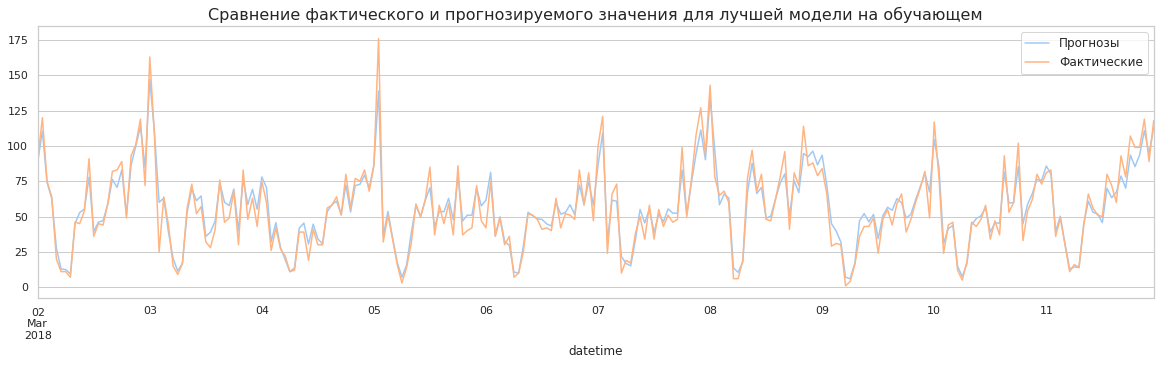

In [ ]:
# прогнозы на 10 дней для тренировочных
pd.DataFrame({'Прогнозы':best_model_rfr.predict(X_train),
             'Фактические':y_train})[:240].plot(figsize=(20,5))
plt.title('Сравнение фактического и прогнозируемого значения для лучшей модели на обучающем')
plt.show()

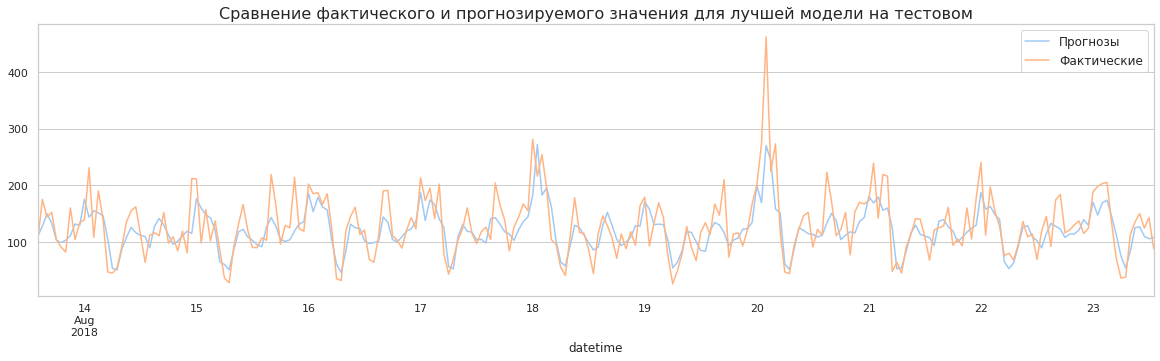

In [ ]:
# прогнозы на 10 дней для тестовых
pd.DataFrame({'Прогнозы':best_model_rfr.predict(X_test),
             'Фактические':y_test})[:240].plot(figsize=(20,5))
plt.title('Сравнение фактического и прогнозируемого значения для лучшей модели на тестовом')
plt.show()

Метрика для кросс-валидации - это оценка обобщающей способности модели (среднее по кросс-валидации). Она является более надежной оценкой, так как учитывает качество модели на данных, которые она не видела во время обучения.

Метрика тренировочной выборки вычислена на всей обучающей выборке после того, как модель была дообучена на всех данных. Это ошибка на обучающих данных, которая обычно ниже, так как модель подстроилась под них.

Большая разница между ними и между тестовой метрикой показывает, что модель переобучилась (разница между train и test RMSE слишком большая). То есть потенциально модель может потребовать доработки (изменение глубины деревьев, добавление регуляризации). Одной из причин переобучения может быть также малое количество данных.

Также на переобучение указывает разность поведения предсказаний для тренировочных и тестовых данных относительно реальных.

Тем не менее, даже переобученная модель показала метрику ниже пороговой (а также на графике пытается повторять истинную кривую), а значит задача заказчика выполнена.

**Вывод**

- Лучшая из моделей показала RMSE на тестовой выборке 43.16, что является ниже 48, требуемых заказчиком. Однако, разница в метриках (кросс-вадидации, тренировочной и тестовых выборок) модели и поведения предсказаний для тестовых и тренировочных данных на графика относительно реальных данных указывает на то, что модель переобучилась, а значит моджет потребовать доработки.
- Модель склонная завышать предсказание для малых количеств, и занижать - для больших.

## Важность признаков (дополнительная работа).

Попробуем изучить важность признаков для нашей модели с помощью SHAP.

In [ ]:
# инициализация explainer (подходит для Random Forest)
explainer = shap.TreeExplainer(best_model_rfr)

In [ ]:
# вычисление SHAP-значений для X_test
shap_values = explainer.shap_values(X_test)

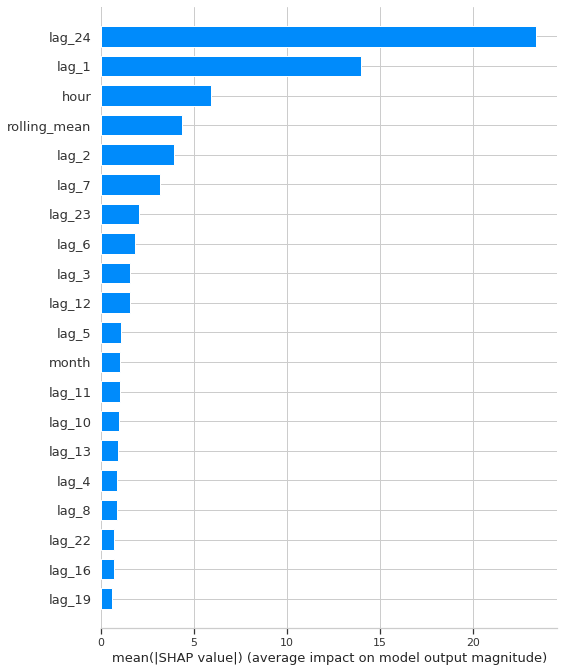

In [ ]:
# График важности признаков (усреднённый)
# увидим "рейтинг признаков" по их влиянию на предсказание
shap.summary_plot(shap_values, X_test, plot_type="bar")

Что можно увидеть:
- Какие лаги наиболее важны.  В нашем случае это `lag_24`, `lag_1`, что мы видели на графике корреляции ранее, а также могли предположить исходя из суточной сезонности.
- Влияют ли скользящие статистики. `rolling_mean` (с данными за неделю) занял четвертое место, поэтому мы можем утверждать, что данный признак оказывает большое влияние на модель.

Также видно, что некоторые лаги оказывают малое влияние на модель, также невелико влияние и у месяца. Возможно в будущем стоит попробовать исключить их из эксперимента.

Также возьмем 24 последних значения и посмотрим, как разные признаки влияют на конкретные предсказания.

In [ ]:
# Выбираем часть временного ряда для визуализации
sample_idx = -24  # последние 24 точек

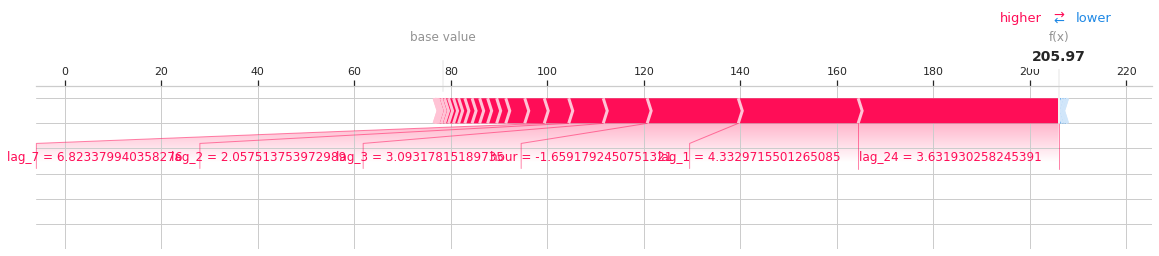

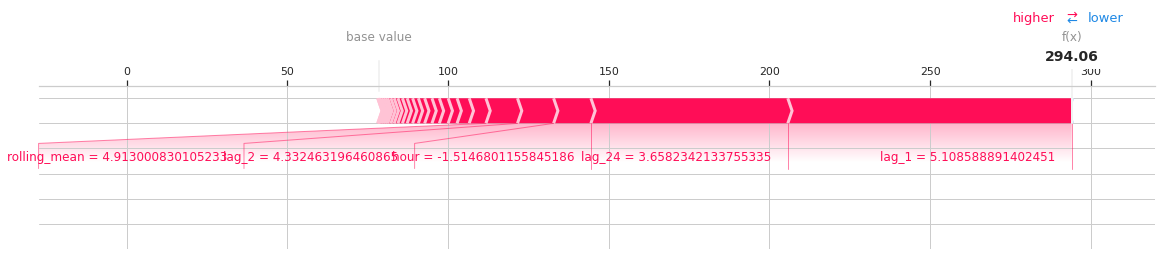

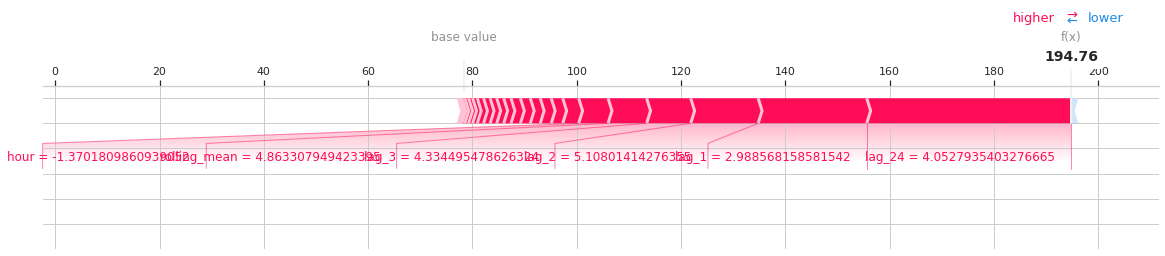

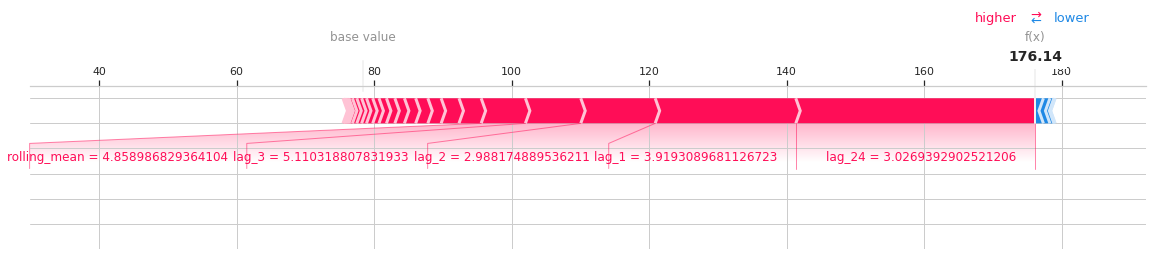

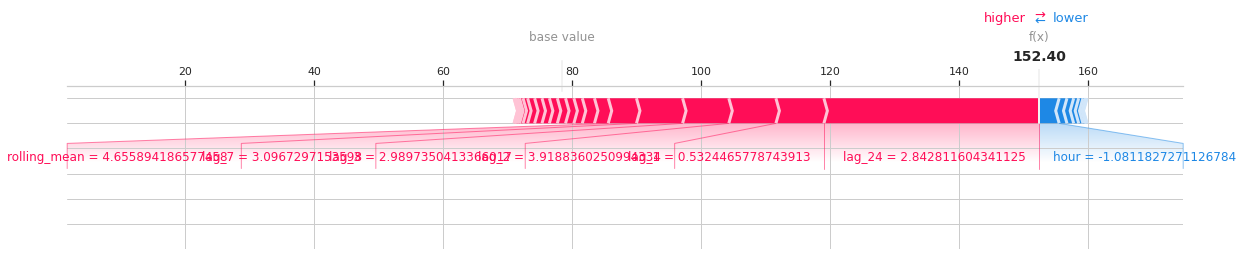

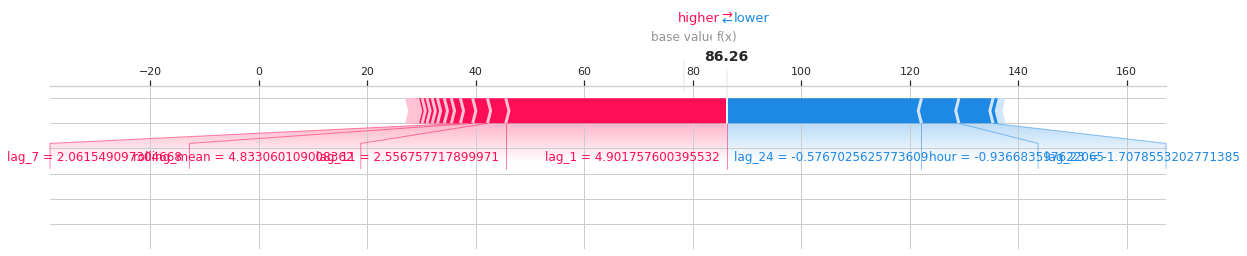

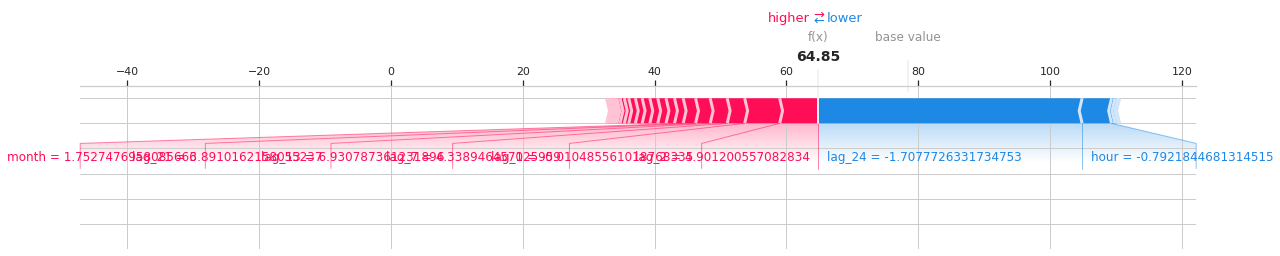

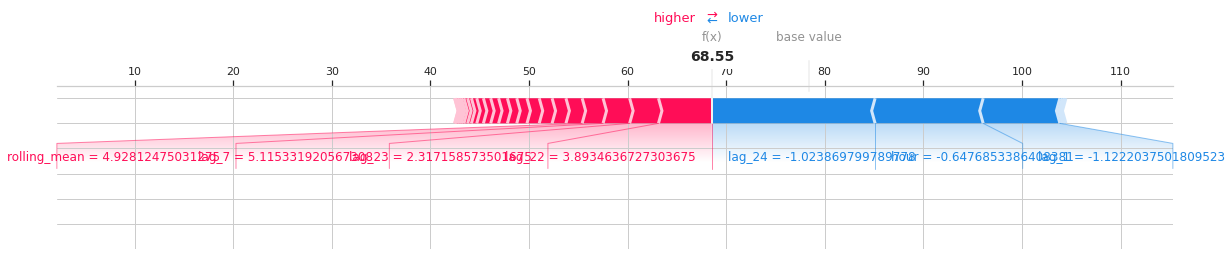

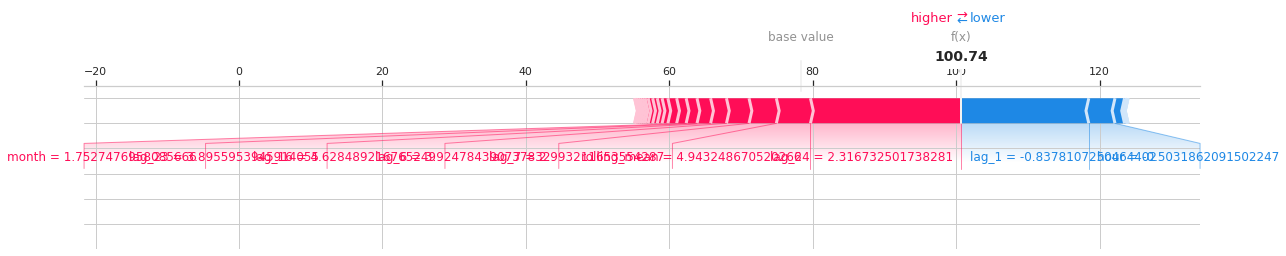

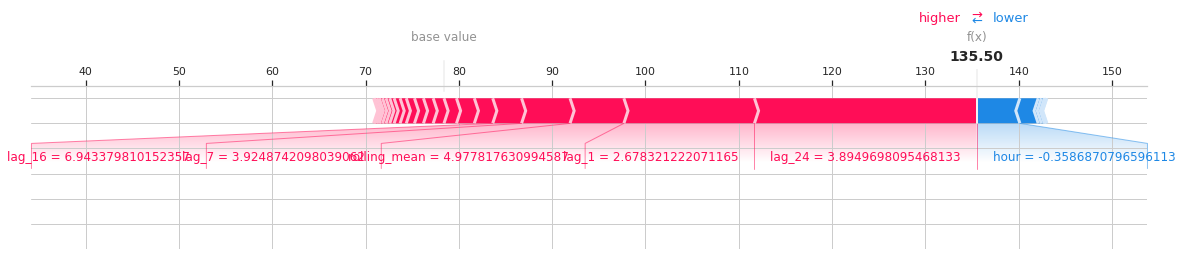

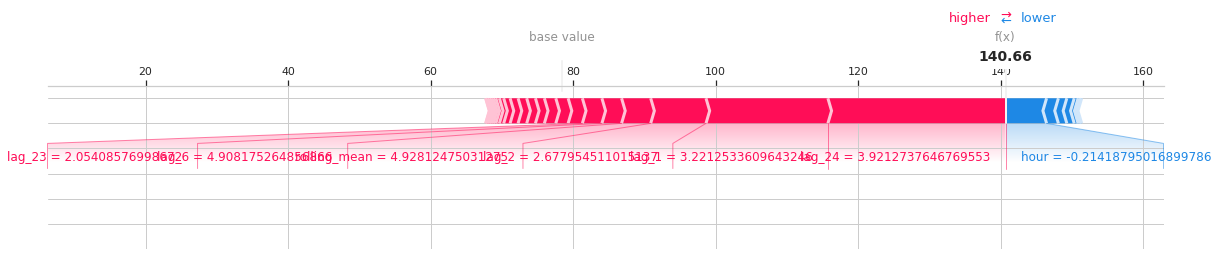

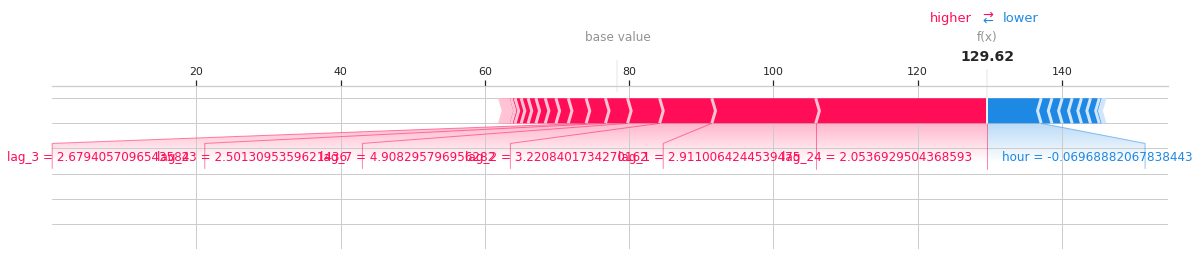

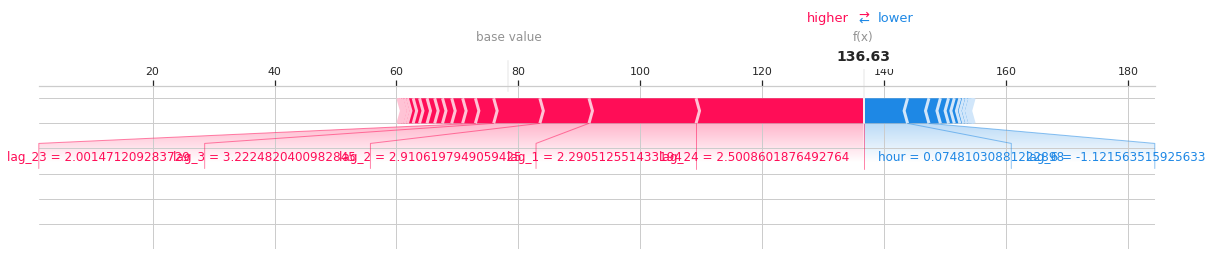

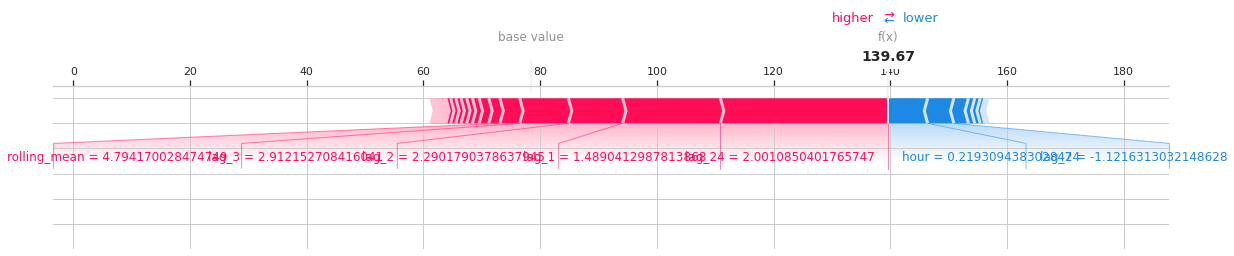

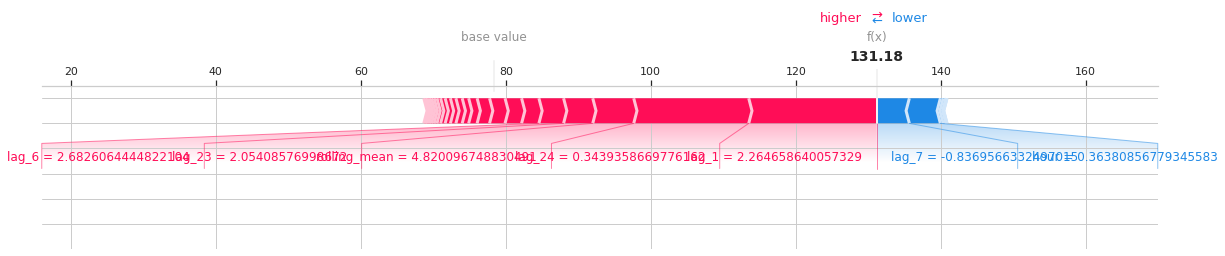

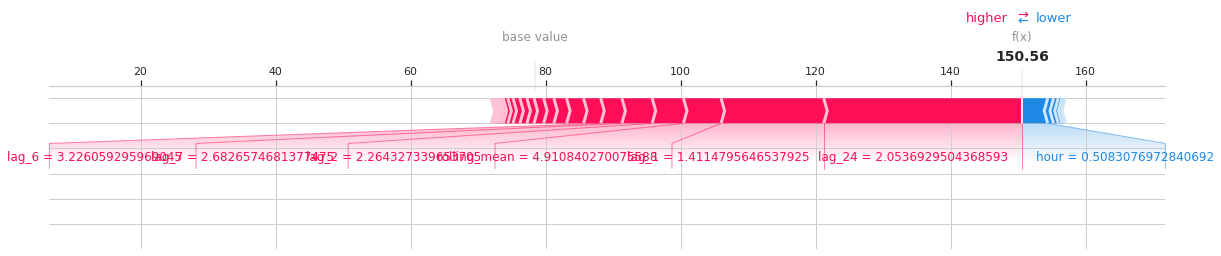

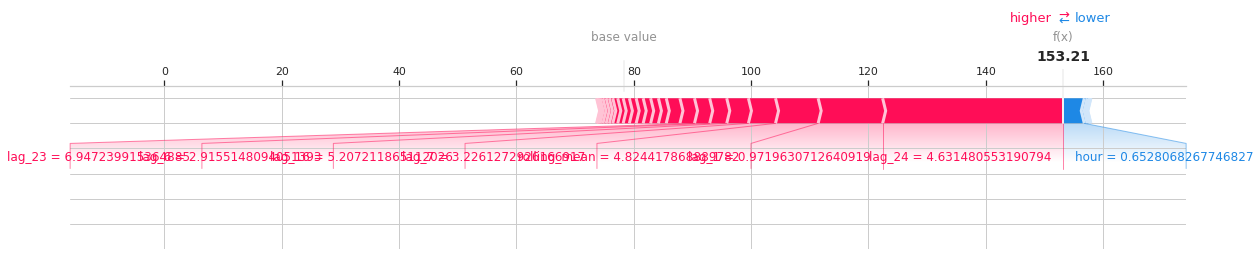

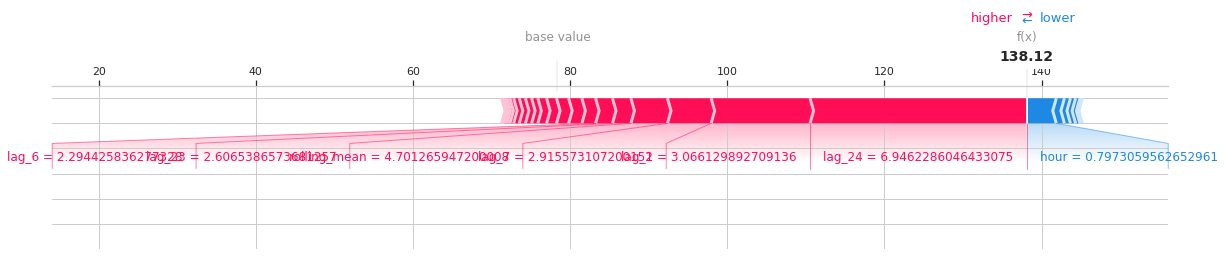

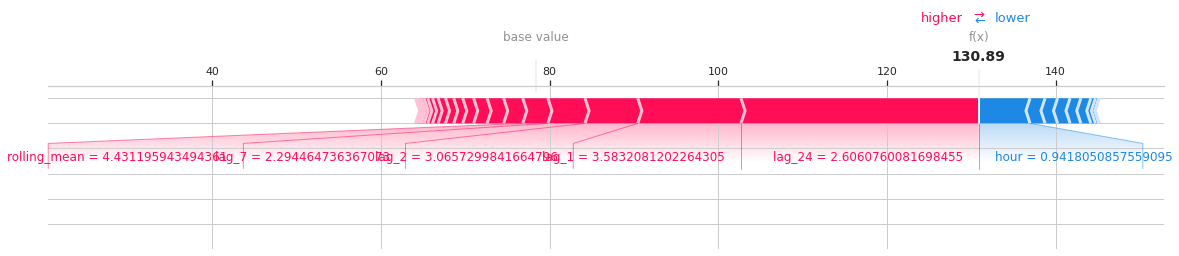

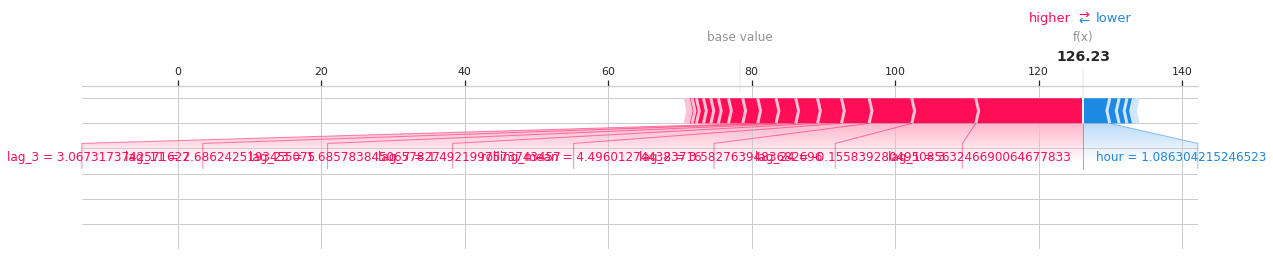

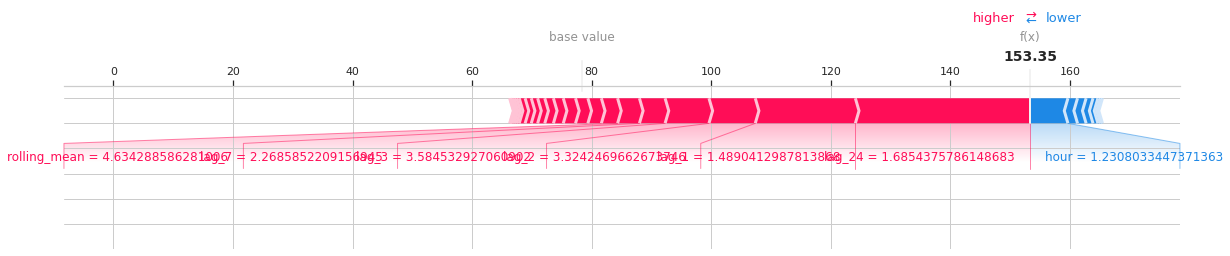

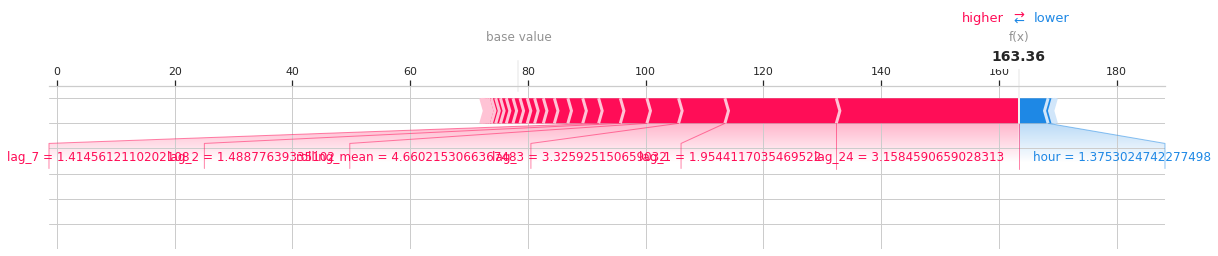

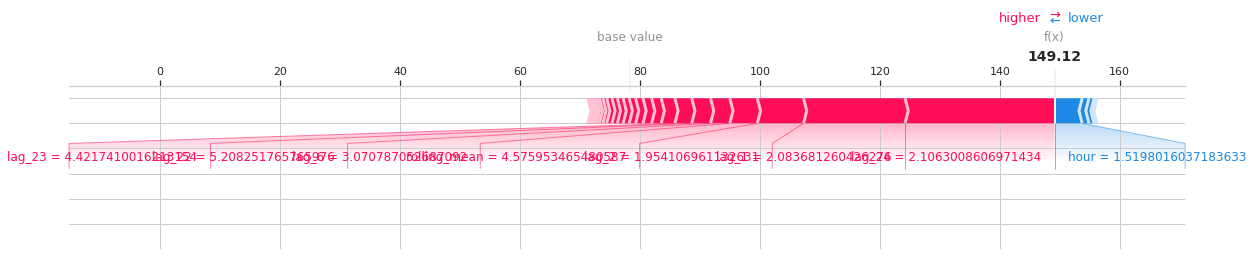

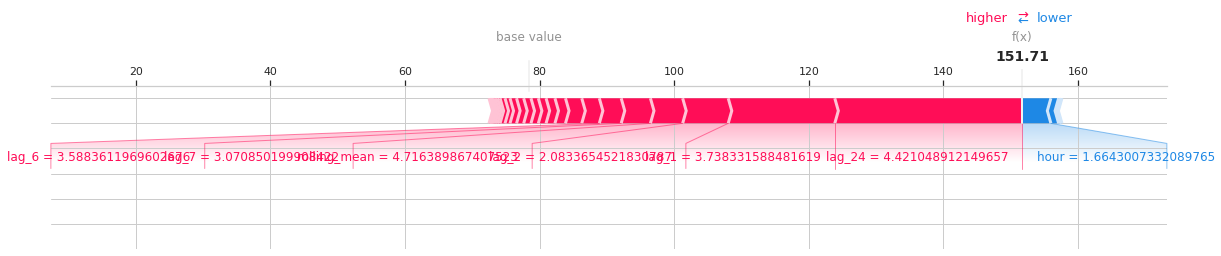

In [ ]:
# визуализируем 10 образцов данных
for i in range(sample_idx, sample_idx + 24):
    shap.force_plot(
        explainer.expected_value,
        shap_values[i],
        X_test.iloc[i],
        matplotlib=True
    )

In [ ]:
# выведем последние значения тренировочного целевого
y_test.tail(24)

datetime
2018-08-31 00:00:00    276
2018-08-31 01:00:00    194
2018-08-31 02:00:00    230
2018-08-31 03:00:00     99
2018-08-31 04:00:00    268
2018-08-31 05:00:00     78
2018-08-31 06:00:00     35
2018-08-31 07:00:00     46
2018-08-31 08:00:00    182
2018-08-31 09:00:00    203
2018-08-31 10:00:00    191
2018-08-31 11:00:00    167
2018-08-31 12:00:00    136
2018-08-31 13:00:00    166
2018-08-31 14:00:00    133
2018-08-31 15:00:00    116
2018-08-31 16:00:00    197
2018-08-31 17:00:00    217
2018-08-31 18:00:00    207
2018-08-31 19:00:00    136
2018-08-31 20:00:00    154
2018-08-31 21:00:00    159
2018-08-31 22:00:00    223
2018-08-31 23:00:00    205
Freq: H, Name: num_orders, dtype: int64

Теперь мы снова видим, что модель склонна занижать результат для больших значений и уменьшать на малых. Потенциально модель требует доработки.

**Вывод**

- Наиболее важные лаги это `lag_24`, `lag_1`, что мы видели на графике корреляции ранее, а также могли предположить исходя из суточной сезонности.
- Скользящая статистика `rolling_mean` (с данными за неделю) заняла четвертое место, поэтому мы можем утверждать, что данный признак оказывает большое влияние на модель.
- Также видно, что некоторые лаги оказываеют малое влияние на модель, также невелико влияние и у месяца. Возможно в будущем стоит попробовать исключить их из эксперимента.
- Модель склонна занижать результат для больших значений и уменьшать на малых. Потенциально модель требует доработки.

## Выводы

Мы изучили данные и разработали модель с метрикой, требуемой заказчиком (RMSE на тестовых данных не превышает 48).

**В процессе изучения данных было установлено, что:**
- Для анализа заказчиком предоставлены данные за период в полгода: c 2018-03-01 00:00:00 по 2018-08-31 23:50:00.
- Отсутствуют данные за 31 марта.
- Распределение количества заказов в час является нормальным и смещенным влево.
- Наиболее сильные выбросы (более 400 заказов в час) приходятся на один и тот же день недели и одно и то же время в августе, что говорит о повторяющемся их характере и том, что данные строки - настоящие. Совпадение дня недели и времени у данных строк может быть связано с прибытием самолета с большим количестовом пассажиров на борту и плохой доступностью общественного транспорта в это время суток.
- Час без заказов за имеющийся период наблюдений случился лишь один раз. Это может быть связано с програмным сбоем в работе сервиса либо обновлением програмного обеспечения, ввиду чего возможность заказа в указанное время была недоступна.
- Виден тренд на увеличение заказов в час: от середнего около 50 в марте, до около 100 и выше в августе. Сам процесс усилинного роста начинается с июня: возможно на него оказывает влияние начало сезона отпусков.
- Имеющися временной ряд нельзя считать стационарным, а пронозировать его будет сложнее из-за изменения свойств.
- Сезонность можно обнаружить в рамках суток:
    * В течении дня несколько пиков, а максимальное количество заказов характерно для времени около полуночи. Это может быть связано как с прибытием междугородного/международного транспорта с большим количеством пассажиров в данное время и/или плохой работой или не работой в это время/в данном месте (например, аэропорт за городом) общественного транспорта, что затрудняет пассажирам путь домой и им приходится вызывать такси.
    * Самое "мертвое" время (с минимальным количеством заказов) - около шести утра.
    
**После анализа новых, созданных под нашу задачу, признаков, мы:**
- Снова увидели рост числа заказов от начала к концу исследуемого периода.
- Обнаружили, что от начала месяца к концу среднее количество заказов растет.
- В пятницу и воскресенье заказов обычно больше всего. Вероятно это может быть связано с поездками на выходные в пятницу и возвращение из никх в воскресенье.
- Для отстающих значений корреляция с целевым признаком присутствует везде, но наиболее тесная - с ближайшими часами до и после.

**В процессе работы с моделями:**
- Было обучена одна базовая и четыре основых моделей. Лучше из которых стала `DecisionTreeRegressor` c RMSE на кросс-валидации  27.51 и 43.16 на тестовых данных.
- Однако лучшая из моделей имеет признаки переобучения, поэтому ей может потребоваться доработка.
- Самыми главными признаками для модели стали `lag_24`, `lag_1`.